# Inspect Data

Playground for various analysis code

In [1]:
import h5py as h5 

import matplotlib.pyplot as plt
from matplotlib import cm, colors
import matplotlib.patches as mpatches
from matplotlib.colors import BoundaryNorm
from matplotlib import colors, ticker

import numpy as np
import os, sys
import traceback
import glob
import pandas as pd

import h5flow 
plt.style.use('../../utils/dune.mplstyle')
from sklearn.cluster import DBSCAN

# Path to repo root (two directories above notebook)
light_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(light_root)

from light.PMT_analysis_utils import * 

# Path to repo root (two directories above notebook)
repo_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.append(repo_root)

from utils.backtracking import get_charge_event_hits, hit_backtracker, get_ancestry # Now this works
from utils.my_ev_display import event_display

### Generate analysis dataframe for hits with good triggers

In [2]:
# Configure your analysis here 
# This debug mode will process only the 10% of the dataset , use this if looking at source data
DEBUG = False

#input_dataset = "/global/cfs/cdirs/dune/www/data/2x2/reflows_run2/v0/flow/ColdOperations/data/2025_Operations_Cold/source/AmBe_1112"
#input_dataset = "/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin2/one_trig_32us_window"
#input_dataset = "/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin0/mod2_pmt_trig"
input_dataset = "/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source"

MULTI = False

out_clusters = "../output/nosource_randtrig_ambe_bin2_one_trig_32us_window_eps1size4.csv"

In [3]:
def filter_hits(hits_set):
    # Remove hits with negative energy
    hits_set = hits_set[hits_set[:,3] > 0.]
    # Remove hits with any NaN field
    hits_set = hits_set[~np.isnan(hits_set).any(axis=1)]
    return hits_set

In [4]:
def CL_AmBe_analysis(input_file,file_id,single=True,clust_eps=1,clust_min_samples=4):
    '''
    Produces AmBe analysis objects

    Column names:
    x, y, z, E, Q, light_id, cluster_label, file_id

    '''

    h5_file = h5flow.data.H5FlowDataManager(input_file,'r')
    g_triggers = None
    b_triggers = None

    # Initialize output dataset 
    out_dataset = {
        "clusters":None
    }

    if(single):
        g_triggers, b_triggers = classify_triggers_single(h5_file,debug=False)
    
    else: 
        first_trig = check_first_trig(h5_file,291)
        parity_str = None
        if(first_trig):
            parity_str = "odd"
        else:
            parity_str = "even"
        print(f"Parity of this file: {parity_str}")
        g_triggers, b_triggers = classify_triggers(h5_file,parity_str,debug=False)

    #print(f"List of good triggers: {g_triggers}")

    # Retrieve products linked to good triggers 
    light_events = h5_file['light/events',g_triggers]
    light_wvfms = h5_file['light/wvfm',g_triggers]
    charge_events = h5_file['light/events','charge/events',g_triggers]
    charge_hits = h5_file['light/events','charge/events','charge/calib_prompt_hits',g_triggers]

    # Charge
    non_zero_charge_hits = charge_hits[charge_events.data['nhit'][:,0] >= 1]
    non_zero_charge_events = charge_events[charge_events.data['nhit'][:,0] >= 1]
    non_zero_charge_light_ev = light_events[charge_events.data['nhit'][:,0] >= 1] 

    E_clusters = []
    n_cluster = [] 
    n_hits_clusters = [] 
    cluster_light_ev_id = [] 

    clusterized_hits = [] 

    db = DBSCAN(eps=clust_eps,min_samples=clust_min_samples)
    for icharge in range(len(non_zero_charge_events)):
    #for icharge in range(2):
        test_event_hits = non_zero_charge_hits[:,0][icharge][0:non_zero_charge_events.data['nhit'][:,0][icharge]]
        this_event_light_id = non_zero_charge_light_ev['id'][icharge]
        hits_stack_unfiltered = np.column_stack((test_event_hits.data['x'],test_event_hits.data['y'],test_event_hits.data['z'],test_event_hits.data['E'],test_event_hits.data['Q'],np.ones(len(test_event_hits))*this_event_light_id))
        hits_stack = filter_hits(hits_stack_unfiltered)
        if(len(hits_stack)==0):
            continue
        labels = db.fit_predict(hits_stack[:,:3])
        hits_stack_label = np.column_stack((hits_stack[:,0],hits_stack[:,1],hits_stack[:,2],hits_stack[:,3],hits_stack[:,4],np.ones(len(hits_stack))*int(this_event_light_id),labels,np.ones(len(hits_stack))*int(file_id)))
        clusterized_hits.extend(hits_stack_label.tolist())
        temp_n_clusters = 0

        for l in np.unique(labels):
            if(l!=-1):
                this_l_hits = hits_stack_label[hits_stack_label[:,6]==l]
                n_hits_clusters.append(len(this_l_hits))
                E_clusters.append(np.sum(this_l_hits[:,3]))
                cluster_light_ev_id.append([l,this_event_light_id])
                temp_n_clusters+=1
            else:
                continue
        n_cluster.append(temp_n_clusters)

    out_dataset["clusters"] = clusterized_hits


    return out_dataset

In [5]:
def get_rand_trig(input_file,file_id,n_trigs,single=True,clust_eps=1,clust_min_samples=4):
    '''
    Produces AmBe analysis objects without light trigger selection

    Column names:
    x, y, z, E, Q, light_id, cluster_label, file_id
    '''

    h5_file = h5flow.data.H5FlowDataManager(input_file,'r')
    g_triggers = None
    b_triggers = None

    # Initialize output dataset
    out_dataset = {
        "clusters":None
    }

    # Randomly sample triggers
    if(single):
        g_triggers = np.random.choice(h5_file['light/events/data']['id'], size=n_trigs, replace=False)
    
    else: 
        first_trig = check_first_trig(h5_file,291)
        parity_str = None
        if(first_trig):
            parity_str = "odd"
        else:
            parity_str = "even"
        print(f"Parity of this file: {parity_str}")
        g_triggers = np.random.choice(h5_file['light/events/data']['id'], size=n_trigs, replace=False)

    #print(f"List of good triggers: {g_triggers}")

    # Retrieve products linked to good triggers 
    light_events = h5_file['light/events',g_triggers]
    light_wvfms = h5_file['light/wvfm',g_triggers]
    charge_events = h5_file['light/events','charge/events',g_triggers]
    charge_hits = h5_file['light/events','charge/events','charge/calib_prompt_hits',g_triggers]

    # Charge
    non_zero_charge_hits = charge_hits[charge_events.data['nhit'][:,0] >= 1]
    non_zero_charge_events = charge_events[charge_events.data['nhit'][:,0] >= 1]
    non_zero_charge_light_ev = light_events[charge_events.data['nhit'][:,0] >= 1] 

    E_clusters = []
    n_cluster = [] 
    n_hits_clusters = [] 
    cluster_light_ev_id = [] 

    clusterized_hits = [] 

    db = DBSCAN(eps=clust_eps,min_samples=clust_min_samples)
    for icharge in range(len(non_zero_charge_events)):
    #for icharge in range(2):
        test_event_hits = non_zero_charge_hits[:,0][icharge][0:non_zero_charge_events.data['nhit'][:,0][icharge]]
        this_event_light_id = non_zero_charge_light_ev['id'][icharge]
        hits_stack_unfiltered = np.column_stack((test_event_hits.data['x'],test_event_hits.data['y'],test_event_hits.data['z'],test_event_hits.data['E'],test_event_hits.data['Q'],np.ones(len(test_event_hits))*this_event_light_id))
        hits_stack = filter_hits(hits_stack_unfiltered)
        if(len(hits_stack)==0):
            continue
        labels = db.fit_predict(hits_stack[:,:3])
        hits_stack_label = np.column_stack((hits_stack[:,0],hits_stack[:,1],hits_stack[:,2],hits_stack[:,3],hits_stack[:,4],np.ones(len(hits_stack))*int(this_event_light_id),labels,np.ones(len(hits_stack))*int(file_id)))
        clusterized_hits.extend(hits_stack_label.tolist())
        temp_n_clusters = 0

        for l in np.unique(labels):
            if(l!=-1):
                this_l_hits = hits_stack_label[hits_stack_label[:,6]==l]
                n_hits_clusters.append(len(this_l_hits))
                E_clusters.append(np.sum(this_l_hits[:,3]))
                cluster_light_ev_id.append([l,this_event_light_id])
                temp_n_clusters+=1
            else:
                continue
        n_cluster.append(temp_n_clusters)

    out_dataset["clusters"] = clusterized_hits


    return out_dataset

In [ ]:
all_clusters = []

for file_count, ifile in enumerate(os.listdir(input_dataset)):

    # Run over 10% of the dataset
    if DEBUG and file_count >= int(len(os.listdir(input_dataset))*0.1):
        break

    this_file = os.path.join(input_dataset, ifile)
    print(this_file)

    try:
        '''
        temp_out = CL_AmBe_analysis(
            this_file,
            file_count,
            single=not MULTI
        )
        '''
        temp_out = get_rand_trig(
            this_file,
            file_count,
            1000,
            single=not MULTI
        )
        all_clusters.extend(temp_out["clusters"])

    except Exception as e:
        print(f"[WARNING] Failed processing {this_file}: {e}")
        continue

all_clusters_array = np.array(all_clusters)

In [ ]:
# Inspect dimensions of different files

for ifile in np.unique(all_clusters_array[:,6]):
    print(f"Dimensions of file {ifile} {all_clusters_array[all_clusters_array[:,6]==ifile].shape}")

In [ ]:
df = pd.DataFrame(all_clusters_array, columns=['x', 'y', 'z', 'E', 'Q', 'light_id', 'cluster_label', 'file_id'])

df["id"] = (
    df["file_id"].astype(str)
    + "::" + df["light_id"].astype(str)
    + "::" + df["cluster_label"].astype(str)
)

df.to_csv(out_clusters)

In [ ]:
df.head()

In [ ]:
# Visualize clustering results

# Energy histogram of individual hits

plt.figure(figsize=(12, 6))

plt.hist(df['E'], color='green', histtype='step', bins=np.arange(0,10,0.2), label='Source Data')

plt.xlabel('Energy of Individual Hits Generated by Neutron (MeV)')
plt.ylabel('Hit Count')
plt.grid(True)
#plt.yscale('log')
#plt.ylim((0,10))
plt.legend()
plt.show()

#### Subsection for Generating Analysis Dataframe for MC

In [ ]:
def filter_hits(hits_set):
    # Remove hits with negative energy
    hits_set = hits_set[hits_set[:,3].astype(float) > 0.]
    # Remove hits with any NaN field
    hits_set = hits_set[~np.isnan(hits_set[:,:5].astype(float)).any(axis=1)]
    return hits_set

In [ ]:
def get_MC(MC_file, clust_eps=1,clust_min_samples=4):
    '''
    Load and cluster MC data, export as df
    '''

    file_id = 0
    mc_hit_arr = np.empty(9)

    # Load MC
    for file in glob.iglob(MC_file):
        with h5.File(file, 'r') as f:
            traj = f['mc_truth/trajectories/data']
            seg = f['mc_truth/segments/data']
            for event_id in np.unique(traj['event_id']):
                my_entry = event_id-1
                ev_traj= traj[traj['event_id']==event_id]
                ev_seg= seg[seg['event_id']==event_id]
                prompt_hits_backtrack, prompt_hits = get_charge_event_hits(my_entry,f)
                new_hits = hit_backtracker(prompt_hits_backtrack, prompt_hits, ev_seg, ev_traj)

                # Exclude negative hits
                positive_hits = new_hits[new_hits['E']>=0]

                # Use parent neutron id as light trigger id since they should correspond with each pmt id from data
                # All cluster ids are -2 for now as placeholder
                # All ids are 'nan' for now as placeholder
                mc_hit_arr = np.vstack([mc_hit_arr, np.column_stack([positive_hits['x'], positive_hits['y'], positive_hits['z'], positive_hits['E'], positive_hits['Q'], positive_hits['parent_neutron_id'], -2*np.ones(len(positive_hits['x'])), file_id*np.ones(len(positive_hits['x'])), np.full(len(positive_hits['x']),fill_value='nan')])])
            file_id += 1

    # Filter hits
    mc_hit_arr = filter_hits(mc_hit_arr)

    mc_df = pd.DataFrame(mc_hit_arr, columns=['x', 'y', 'z', 'E', 'Q', 'light_id', 'cluster_label', 'file_id', 'id'])

    # Perform clustering
    db = DBSCAN(eps=clust_eps,min_samples=clust_min_samples)
    # Generate a list of unique light trig_ids
    trig_ids = mc_df['file_id'].astype(str)+ '::' + mc_df['light_id'].astype(str)
    mc_hit_trig_ids = mc_hit_arr[:,7].astype(str) + '::' + mc_hit_arr[:,5].astype(str)
    for i in np.unique(mc_hit_trig_ids):
        labels = db.fit_predict(mc_hit_arr[:,:3][trig_ids==i].astype(float))
        # Change cluster labels to results based on the overlay
        mc_df.loc[trig_ids==i,'cluster_label'] = labels
        # temporarily define the ids of clustered hits as something identifiable
        mc_df.loc[trig_ids==i,'id'] = 'clustered'

    final_mc_df = mc_df.drop(np.where(mc_df['id']!='clustered')[0])
    final_mc_df['id']=final_mc_df['file_id'].astype(str) +'::'+ final_mc_df['light_id'].astype(str) +'::'+ final_mc_df['cluster_label'].astype(str)
    print(f'Total number of neutrons in MC file: {len(np.unique(mc_hit_trig_ids))}')
    return final_mc_df

In [ ]:
# Generate analysis dataframe

MC_data = '/global/cfs/cdirs/dune/users/lmlepin/2x2_neutron_prod/AmBe_top_mod2_PROD_03-21/FLOW/*.hdf5'
#MC_data = '/global/cfs/cdirs/dune/users/lmlepin/2x2_neutron_prod/AmBe_top_mod2_PROD_03-21/FLOW/2x2_QGSP_BERT_HP_AmBe_1774119367_0_TIME_MOD.FLOW.hdf5'

#df_MC = get_MC(MC_data)
df_MC = get_MC(MC_data, clust_eps=1, clust_min_samples=3)

In [ ]:
df_MC

In [ ]:
# Export the MC data as df

#df_MC.to_csv("../output/MC_AmBe_Prod_03-21_eps1size4.csv")
df_MC.to_csv("../output/eps1_minsamples3/MC_AmBe_Prod_05-29_eps1size3.csv")

### Load Datasets

In [2]:
# Load source data
df = pd.read_csv('../output/source_ambe_bin2_one_trig_32us_window_clusters_with_source.csv')

# Load source data clustered with more stringent parameters
#df_eps1size4 = pd.read_csv('../output/source_ambe_bin2_one_trig_32us_window_eps1size4.csv')

# Load no source data
df_nosource = pd.read_csv('../output/source_ambe_bin2_one_trig_32us_window_clusters.csv')

# Load source data clustered with eps=1cm, minimum_cluster_size=4
df_eps1size4 = pd.read_csv('../output/eps1_minsamples4/ambe_bin2_one_trig_32us_window_eps1size4.csv')

# Load no source data clustered with eps=1cm, minimum_cluster_size=4
df_nosource_eps1size4 = pd.read_csv('../output/eps1_minsamples4/nosource_ambe_bin2_one_trig_32us_window_eps1size4.csv')

# Load no source data with more stringent parameters and randomly chosen triggers
#df_nosource_eps1size4_randtrig = pd.read_csv('../output/nosource_randtrig_ambe_bin2_one_trig_32us_window_eps1size4.csv')

### Normalize all data in terms of run time

This might be a temporary solution. Calculate the trigger rate of all files used in the plots above, then resample the triggers to that rate and redo the comparison

In [3]:
# Calculate trigger rate of all files

def get_runtime(input_dataset, DEBUG=True):
    runtime = 0
    for file_count, ifile in enumerate(os.listdir(input_dataset)):
        # Run over 10% of the dataset
        if DEBUG and file_count >= int(len(os.listdir(input_dataset))*0.1):
            break

        this_file = os.path.join(input_dataset, ifile)
        h5_file = h5flow.data.H5FlowDataManager(this_file,'r')
        # file_duration is in units of seconds
        file_duration = max(h5_file['charge/events/data']['unix_ts'])-min(h5_file['charge/events/data']['unix_ts'])
        runtime += file_duration

    return runtime

In [4]:
# Get total duration of all files
no_source_runtime = get_runtime('/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source')
source_runtime = get_runtime('/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin2/one_trig_32us_window')

In [5]:
print(source_runtime)
print(no_source_runtime)

581
196


In [6]:
df_eps1size4_trig_ids = df_eps1size4['file_id'].astype(str)+ '::' + df_eps1size4['light_id'].astype(str)
df_nosource_eps1size4_trig_ids = df_nosource_eps1size4['file_id'].astype(str)+ '::' + df_nosource_eps1size4['light_id'].astype(str)

In [7]:
# Note that MC has more neutrons than there are triggers

#print(len(MC_trig_ids))
print(len(np.unique(df_nosource_eps1size4_trig_ids)))

26916


In [8]:
# Sample triggers from datasets normalized by run time
if source_runtime >= no_source_runtime:
    print('Source present data has more runtime')
    n_source = int(len(np.unique(df_eps1size4_trig_ids))*(no_source_runtime/source_runtime))
    n_nosource = len(np.unique(df_nosource_eps1size4_trig_ids))
else:
    print('No source data has more runtime')

Source present data has more runtime


In [9]:
print(n_source)
print(n_nosource)

28968
26916


### Recalibrate energy

In [10]:
def charge_to_energy_mev(charge_ke):
    return (np.asarray(charge_ke, dtype=np.float64) * 1e3 * 23.6) / 0.57523585 / 1e6

In [11]:
df_eps1size4['E'] = charge_to_energy_mev(df_eps1size4['Q'])
df_nosource_eps1size4['E'] = charge_to_energy_mev(df_nosource_eps1size4['Q'])

### Compare datasets

In [12]:
# Get cluster energies and cluster hit count

source_eps1size4_clusteredhits = pd.DataFrame(np.empty((0,9)), columns=['x', 'y', 'z', 'E', 'Q', 'light_id', 'cluster_label', 'file_id', 'id'])
source_eps1size4_clusterE = []
source_eps1size4_clusterhitcount = []

nosource_eps1size4_clusteredhits = pd.DataFrame(np.empty((0,9)), columns=['x', 'y', 'z', 'E', 'Q', 'light_id', 'cluster_label', 'file_id', 'id'])
nosource_eps1size4_clusterE = []
nosource_eps1size4_clusterhitcount = []


for i in np.unique(df_eps1size4_trig_ids)[:n_source]:
    temp_hits = df_eps1size4[(df_eps1size4_trig_ids==i) & (df_eps1size4['cluster_label']!=-1)]
    if len(temp_hits):
        source_eps1size4_clusteredhits = pd.concat([source_eps1size4_clusteredhits, temp_hits])
    for j in np.unique(temp_hits['id']):
        if 10>=sum(temp_hits['E'][temp_hits['id']==j])>=6.0:
            print(f"Cosmic-like{temp_hits['id']}")
        elif 2.0>=sum(temp_hits['E'][temp_hits['id']==j]):
            print(f"Noise-like{temp_hits['id']}")
        elif 6.0>=sum(temp_hits['E'][temp_hits['id']==j])>=2.0:
            print(f"Capture-like{temp_hits['id']}")
        else:
            pass
        source_eps1size4_clusterE.append(sum(temp_hits['E'][temp_hits['id']==j]))
        source_eps1size4_clusterhitcount.append(len(temp_hits['E'][temp_hits['id']==j]))

print('1/2 Completed')

for i in np.unique(df_nosource_eps1size4_trig_ids)[:n_nosource]:
    temp_hits = df_nosource_eps1size4[(df_nosource_eps1size4_trig_ids==i) & (df_nosource_eps1size4['cluster_label']!=-1)]
    #temp_ids = df_nosource_eps1size4_randtrig['id'][(df_nosource_eps1size4_randtrig_trig_ids==i) & (df_nosource_eps1size4_randtrig['cluster_label']!=-1)]
    if len(temp_hits):
        nosource_eps1size4_clusteredhits = pd.concat([nosource_eps1size4_clusteredhits, temp_hits])
    for j in np.unique(temp_hits['id']):
        nosource_eps1size4_clusterE.append(sum(temp_hits['E'][temp_hits['id']==j]))
        nosource_eps1size4_clusterhitcount.append(len(temp_hits['E'][temp_hits['id']==j]))

print('2/2 Completed')

Capture-like1484    0.0::1022.0::0.0
1485    0.0::1022.0::0.0
1486    0.0::1022.0::0.0
1487    0.0::1022.0::0.0
1488    0.0::1022.0::0.0
1489    0.0::1022.0::0.0
1490    0.0::1022.0::0.0
1491    0.0::1022.0::0.0
1492    0.0::1022.0::0.0
Name: id, dtype: object
Capture-like1687    0.0::1186.0::0.0
1688    0.0::1186.0::0.0
1689    0.0::1186.0::0.0
1690    0.0::1186.0::0.0
1692    0.0::1186.0::0.0
1693    0.0::1186.0::0.0
Name: id, dtype: object
Noise-like191    0.0::128.0::0.0
192    0.0::128.0::0.0
193    0.0::128.0::0.0
194    0.0::128.0::0.0
Name: id, dtype: object
Noise-like1992    0.0::1325.0::0.0
1993    0.0::1325.0::0.0
1994    0.0::1325.0::0.0
1995    0.0::1325.0::0.0
Name: id, dtype: object
Capture-like2032    0.0::1360.0::0.0
2033    0.0::1360.0::0.0
2034    0.0::1360.0::0.0
2035    0.0::1360.0::0.0
2036    0.0::1360.0::0.0
Name: id, dtype: object
Capture-like2048    0.0::1362.0::0.0
2049    0.0::1362.0::0.0
2050    0.0::1362.0::0.0
2051    0.0::1362.0::0.0
Name: id, dtype: obj

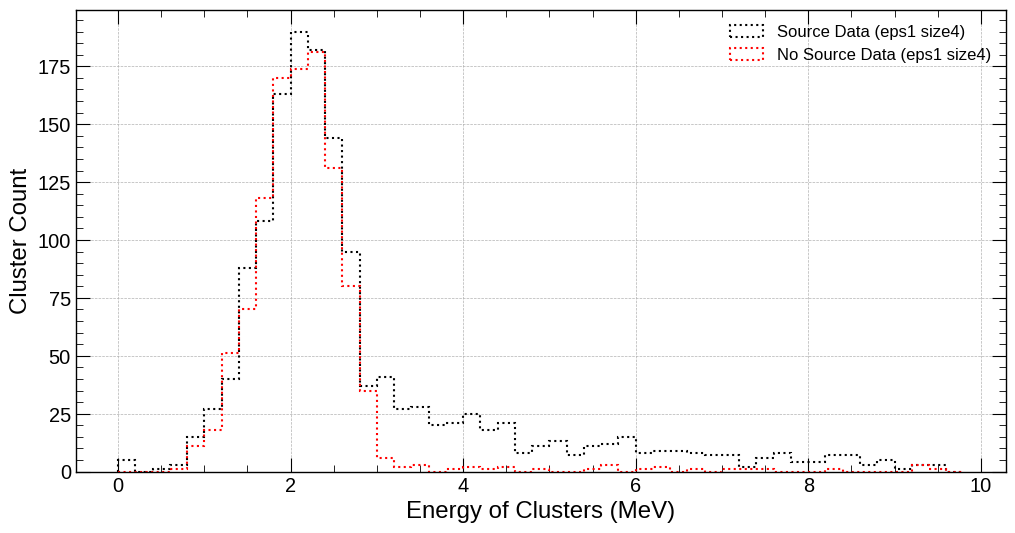

In [13]:
# Visualize and compare

# Cluster energy

plt.figure(figsize=(12, 6))

plt.hist(source_eps1size4_clusterE, color='black', linestyle=':', histtype='step', bins=np.arange(0,10,0.2), label='Source Data (eps1 size4)')
plt.hist(nosource_eps1size4_clusterE, color='red', linestyle=':', histtype='step', bins=np.arange(0,10,0.2), label='No Source Data (eps1 size4)')

plt.xlabel('Energy of Clusters (MeV)')
plt.ylabel('Cluster Count')
plt.grid(True)
#plt.yscale('log')
#plt.ylim((0,10))
plt.legend()
plt.show()

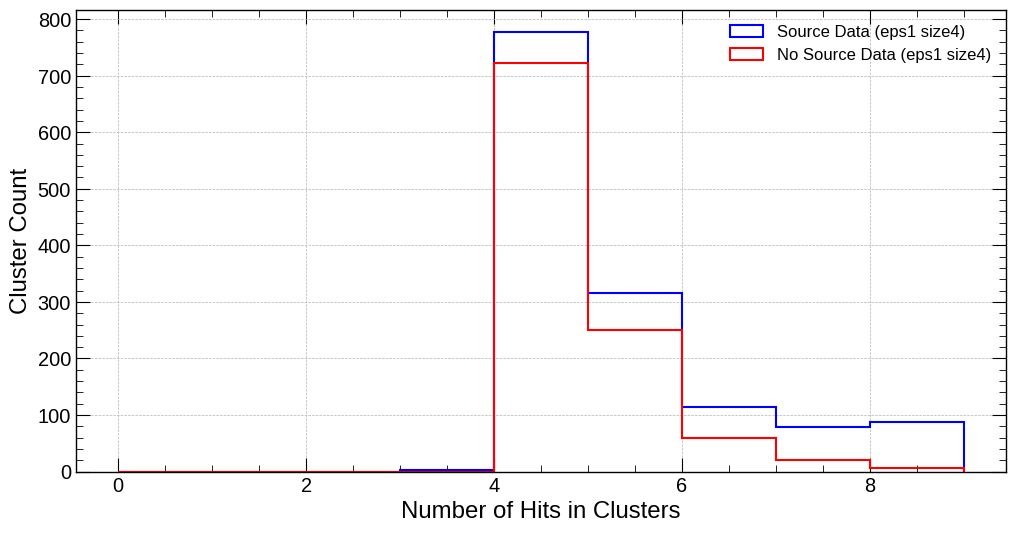

In [14]:
# Cluster hit count

plt.figure(figsize=(12, 6))

plt.hist(source_eps1size4_clusterhitcount, color='blue', histtype='step', bins=np.arange(0,10,1), label='Source Data (eps1 size4)')
plt.hist(nosource_eps1size4_clusterhitcount, color='red', histtype='step', bins=np.arange(0,10,1), label='No Source Data (eps1 size4)')

plt.xlabel('Number of Hits in Clusters')
plt.ylabel('Cluster Count')
plt.grid(True)
#plt.yscale('log')
#plt.ylim((0,10))
plt.legend()
plt.show()

In [15]:
source_eps1size4_clusterE = np.array(source_eps1size4_clusterE)
source_eps1size4_clusterhitcount = np.array(source_eps1size4_clusterhitcount)

nosource_eps1size4_clusterE = np.array(nosource_eps1size4_clusterE)
nosource_eps1size4_clusterhitcount = np.array(nosource_eps1size4_clusterhitcount)

In [16]:
# Divide up the clusters with less than 5 hits and more than 5 hits

source_eps1size4_capturelike_E = source_eps1size4_clusterE[source_eps1size4_clusterhitcount>=5]
source_eps1size4_inelasticlike_E = source_eps1size4_clusterE[source_eps1size4_clusterhitcount<5]

nosource_eps1size4_capturelike_E = nosource_eps1size4_clusterE[nosource_eps1size4_clusterhitcount>=5]
nosource_eps1size4_inelasticlike_E = nosource_eps1size4_clusterE[nosource_eps1size4_clusterhitcount<5]

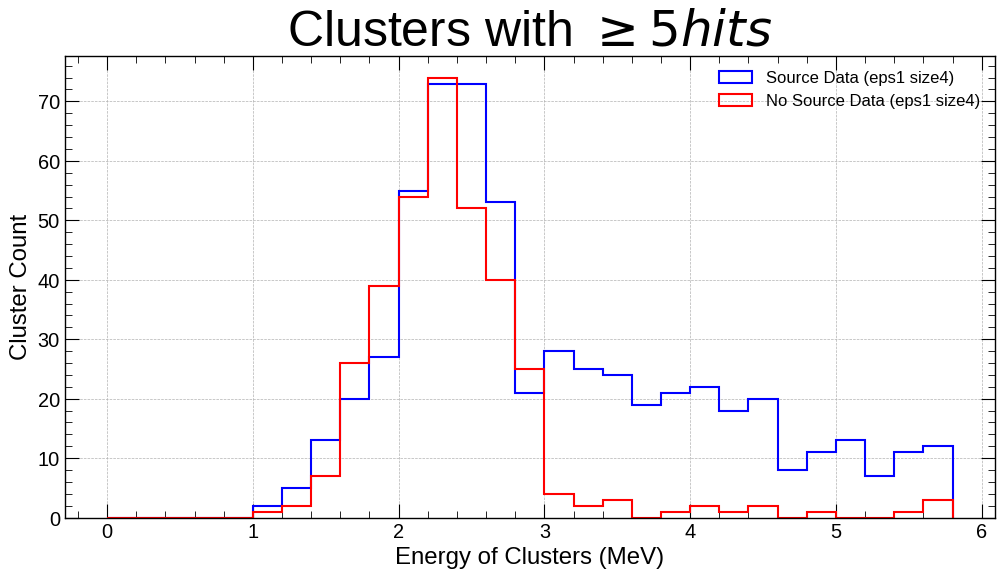

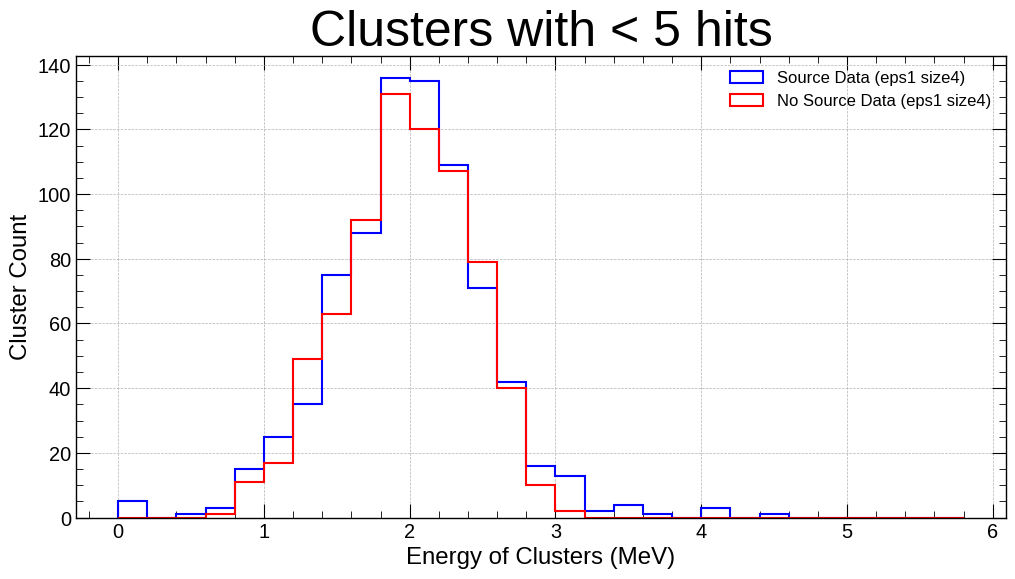

In [17]:
# Cluster energy

plt.figure(figsize=(12, 6))

plt.hist(source_eps1size4_capturelike_E, color='blue', histtype='step', bins=np.arange(0,6,0.2), label='Source Data (eps1 size4)')
plt.hist(nosource_eps1size4_capturelike_E, color='red', histtype='step', bins=np.arange(0,6,0.2), label='No Source Data (eps1 size4)')

plt.xlabel('Energy of Clusters (MeV)')
plt.ylabel('Cluster Count')
plt.title(r'Clusters with $\geq 5 hits$')
plt.grid(True)
#plt.yscale('log')
#plt.ylim((0,10))
plt.legend()
plt.show()


plt.figure(figsize=(12, 6))

plt.hist(source_eps1size4_inelasticlike_E, color='blue', histtype='step', bins=np.arange(0,6,0.2), label='Source Data (eps1 size4)')
plt.hist(nosource_eps1size4_inelasticlike_E, color='red', histtype='step', bins=np.arange(0,6,0.2), label='No Source Data (eps1 size4)')

plt.xlabel('Energy of Clusters (MeV)')
plt.ylabel('Cluster Count')
plt.title('Clusters with < 5 hits')
plt.grid(True)
#plt.yscale('log')
#plt.ylim((0,10))
plt.legend()
plt.show()

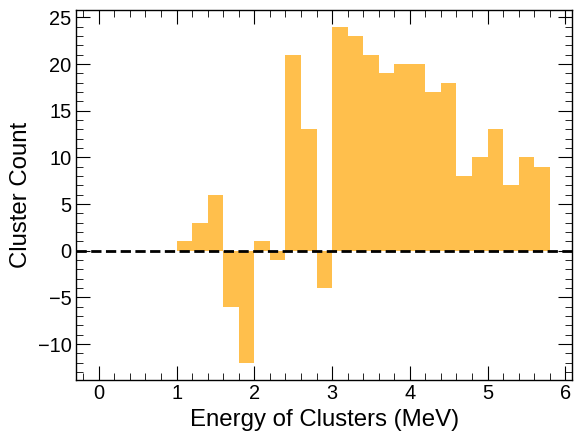

In [18]:
# Plot the difference
bins_range = np.arange(0,6,0.2)
counts1, _ = np.histogram(source_eps1size4_capturelike_E, bins=bins_range)
counts2, _ = np.histogram(nosource_eps1size4_capturelike_E, bins=bins_range)

# Calculate the difference
diff = counts1 - counts2

# Plot the difference
plt.bar(bins_range[:-1], diff, width=np.diff(bins_range), align='edge', color='orange', alpha=0.7)
plt.xlabel('Energy of Clusters (MeV)')
plt.ylabel('Cluster Count')
plt.axhline(0, color='black', linestyle='--') # Add baseline
plt.show()

In [ ]:
# Function to calculate density of individual clusters

def get_hit_density(data_array):
    '''
    Calculate hit and charge density of clusters

    Hit/Charge density: The density of hits/charge in a spherical volume whose diameter is defined by the furthest two points in a cluster

    Output: Hit Density, Charge Density
    '''

    volume = []
    tot_charge = []
    hitnum = []

    for i in np.unique(data_array['id']):
        temp_arr = data_array[data_array['id']==i]
        temp_locs = np.column_stack((temp_arr['x'],temp_arr['y'],temp_arr['z']))
        max_dist_sq = 0

        for i in range(len(temp_arr)):
            diff = temp_locs[i+1:] - temp_locs[i]
            dist_sq = np.sum(diff**2, axis=1)
            
            if len(dist_sq) > 0:
                max_dist_sq = max(max_dist_sq, dist_sq.max())
            else:
                pass

        max_dist = np.sqrt(max_dist_sq)

        volume.append(4/3*np.pi*(max_dist/2)**3)
        tot_charge.append(sum(temp_arr['Q']))
        hitnum.append(len(temp_arr))

    volume = np.array(volume)
    tot_charge = np.array(tot_charge)
    hitnum = np.array(hitnum)

    return hitnum, tot_charge, hitnum/volume, tot_charge/volume

In [ ]:
# Generate hit/charge density data

source_eps1size4_clusthitnum, source_eps1size4_clustQ, source_eps1size4_hitdensity, source_eps1size4_chargedensity = get_hit_density(source_eps1size4_clusteredhits)
nosource_eps1size4_clusthitnum, nosource_eps1size4_clustQ, nosource_eps1size4_hitdensity, nosource_eps1size4_chargedensity = get_hit_density(nosource_eps1size4_clusteredhits)

In [ ]:
# Compare charge vs hit density

plt.hist2d(source_eps1size4_hitdensity, source_eps1size4_chargedensity, bins=30)
cb = plt.colorbar()
cb.set_label('Cluster Counts')
plt.xlabel(r'Hit Density (Hit/$cm^3$)')
plt.ylabel(r'Charge Density (k$e^-$/$cm^3$)')
plt.title('Charge Density vs Hit Density')
plt.show()

plt.hist2d(nosource_eps1size4_hitdensity, nosource_eps1size4_chargedensity, bins=30)
cb = plt.colorbar()
cb.set_label('Cluster Counts')
plt.xlabel(r'Hit Density (Hit/$cm^3$)')
plt.ylabel(r'Charge Density (k$e^-$/$cm^3$)')
plt.title('Charge Density vs Hit Density (no source)')
plt.show()

In [ ]:
# Visualize and compare

# Cluster charge

plt.figure(figsize=(12, 6))

plt.hist(source_eps1size4_clustQ, color='blue', histtype='step', bins=np.arange(0,1000,10), label='Source Data (eps1 size4)')
plt.hist(nosource_eps1size4_clustQ, color='red', histtype='step', bins=np.arange(0,1000,10), label='No Source Data (eps1 size4)')

plt.xlabel(r'Cluster Total Charge (k$e^-$)')
plt.ylabel('Cluster Count')
plt.grid(True)
#plt.yscale('log')
#plt.ylim((0,10))
plt.legend()
plt.show()

In [ ]:
# 2d histogram of cluster total charge vs cluster charge density

plt.hist2d(source_eps1size4_chargedensity, source_eps1size4_clustQ, bins=[np.arange(0,600,5), np.arange(0,800,10)])
cb = plt.colorbar()
cb.set_label('Cluster Counts')
plt.xlabel(r'Charge Density (k$e^-$/$cm^3$)')
plt.ylabel(r'Cluster Total Charge (k$e^-$)')
plt.title('Cluster Total Charge vs Charge Density')
plt.show()

plt.hist2d(nosource_eps1size4_chargedensity, nosource_eps1size4_clustQ, bins=[np.arange(0,600,5), np.arange(0,800,10)])
cb = plt.colorbar()
cb.set_label('Cluster Counts')
plt.xlabel(r'Charge Density (k$e^-$/$cm^3$)')
plt.ylabel(r'Cluster Total Charge (k$e^-$)')
plt.title('Cluster Total Charge vs Charge Density (no source)')
plt.show()

In [ ]:
# 2d histogram of number of hits vs cluster charge density

plt.hist2d(source_eps1size4_chargedensity, source_eps1size4_clusthitnum, bins=[np.arange(0,600,5), np.arange(3,20,1)])
cb = plt.colorbar()
cb.set_label('Cluster Counts')
plt.xlabel(r'Charge Density (k$e^-$/$cm^3$)')
plt.ylabel(r'Number of Hits')
plt.title('Number of Hits vs Charge Density')
plt.show()

plt.hist2d(nosource_eps1size4_chargedensity, nosource_eps1size4_clusthitnum, bins=[np.arange(0,600,5), np.arange(3,20,1)])
cb = plt.colorbar()
cb.set_label('Cluster Counts')
plt.xlabel(r'Charge Density (k$e^-$/$cm^3$)')
plt.ylabel(r'Number of Hits')
plt.title('Number of Hits vs Charge Density (no source)')
plt.show()

### Use cosmics data to perform MC+Background overlay

In [19]:
def load_MC(MC_file):

    '''
    Load MC data into a dataframe
    '''

    file_id = 0
    mc_hit_arr = np.empty(9)

    # Load MC
    for file in glob.iglob(MC_file):
        with h5.File(file, 'r') as f:
            traj = f['mc_truth/trajectories/data']
            seg = f['mc_truth/segments/data']
            for event_id in np.unique(traj['event_id']):
                my_entry = event_id-1
                ev_traj= traj[traj['event_id']==event_id]
                ev_seg= seg[seg['event_id']==event_id]
                prompt_hits_backtrack, prompt_hits = get_charge_event_hits(my_entry,f)
                new_hits = hit_backtracker(prompt_hits_backtrack, prompt_hits, ev_seg, ev_traj)

                # Exclude negative hits
                positive_hits = new_hits[new_hits['E']>=0]

                # Use parent neutron id as light trigger id since they should correspond with each pmt id from data
                # All cluster ids are -2 for now as placeholder
                # All ids are 'nan' for now as placeholder
                mc_hit_arr = np.vstack([mc_hit_arr, np.column_stack([positive_hits['x'], positive_hits['y'], positive_hits['z'], positive_hits['E'], positive_hits['Q'], 1.0*positive_hits['parent_neutron_id'], -2*np.ones(len(positive_hits['x'])), file_id*np.ones(len(positive_hits['x'])), np.full(len(positive_hits['x']),fill_value='nan')])])
            file_id += 1

    mc_df = pd.DataFrame(mc_hit_arr, columns=['x', 'y', 'z', 'E', 'Q', 'light_id', 'cluster_label', 'file_id', 'id'])
    return mc_df

In [20]:
cosmic_data = '/global/cfs/cdirs/dune/users/edgarmao/NeutronSim/Analysis/2x2_neutron_sources/AmBe/output/eps1_minsamples4/nosource_ambe_bin2_one_trig_32us_window_eps1size4.csv'
#MC_data = '/global/cfs/cdirs/dune/users/lmlepin/2x2_neutron_prod/AmBe_tests/2x2_AmBe_in_mod2_prompt_window_test_11-19-2025_MOD.FLOW.hdf5'
#MC_data = '/global/cfs/cdirs/dune/users/lmlepin/2x2_neutron_prod/AmBe_Prod_V4/FLOW/*.hdf5'
MC_data = '/global/cfs/cdirs/dune/users/lmlepin/2x2_neutron_prod/AmBe_top_mod2_PROD_03-21/FLOW/*.hdf5'
#MC_data = '/global/cfs/cdirs/dune/users/lmlepin/2x2_neutron_prod/AmBe_top_mod2_PROD_03-21/FLOW/2x2_QGSP_BERT_HP_AmBe_1774119367_0_TIME_MOD.FLOW.hdf5'

In [21]:
MC_df = load_MC(MC_data)

In [22]:
# Recalibrate energy
MC_df['E'] = charge_to_energy_mev(MC_df['Q'])

In [23]:
def overlay_MC_Cosmic(cosmic_file, mc_df, clust_eps=1,clust_min_samples=4):
    '''
    Overlap each MC event (currently without light info) with a cosmic event to generate a new dataframe
    
    If there are less cosmic triggers than MC events there will be a notice of how many events were successfully overlapped

    Overlay dataframes will contain an extra column flagging which events were overlaid (overlay_label = 1) vs which event is just from a no source trigger (overlay_label = 0)

    '''
    cosmic_df = pd.read_csv(cosmic_file, index_col=0)

    # Recalibrate hit energy
    cosmic_df['E'] = charge_to_energy_mev(cosmic_df['Q'])

    mc_hit_trig_ids = mc_df['file_id'].astype(str) + '::' + mc_df['light_id'].astype(str)
    mc_hit_trig_ids_unique = np.unique(mc_hit_trig_ids)
    # Generate a list of cosmic trig ids that have hits in them
    cosmic_og_trig_ids = cosmic_df['file_id'].astype(str)+ '::' + cosmic_df['light_id'].astype(str)
    cosmic_og_trig_ids_wclusters = np.array(cosmic_og_trig_ids[cosmic_df['cluster_label']!=-1])
    cosmic_og_trig_ids_wclusters_unique = np.unique(cosmic_og_trig_ids_wclusters)

    print('begin overlay')

    snr = 0.1    # Signal to Noise Ratio: Number of MC events / Number of background events
    # Empty array for overlays
    overlay_arr = np.empty(10)
    for i in range(min([len(mc_hit_trig_ids_unique), len(cosmic_og_trig_ids_wclusters_unique)])):
        cosmic_temp = cosmic_df[cosmic_og_trig_ids==cosmic_og_trig_ids_wclusters_unique[i]]
        # Change file and light ids of the cosmic trigs
        cosmic_temp.loc[:,'file_id'] = float(mc_hit_trig_ids_unique[i].split('::')[0])
        cosmic_temp.loc[:,'light_id'] = float(mc_hit_trig_ids_unique[i].split('::')[1])
        if snr*i%1==0:
            arr_to_stack = np.vstack([mc_df[mc_hit_trig_ids==mc_hit_trig_ids_unique[i]], cosmic_temp])
            arr_to_stack = np.column_stack([arr_to_stack, np.ones(len(arr_to_stack)).T])
            overlay_arr = np.vstack([overlay_arr, arr_to_stack])
        else:
            # pass through the process without overlaying an event
            arr_to_stack = np.column_stack([cosmic_temp, np.zeros(len(cosmic_temp)).T])
            overlay_arr = np.vstack([overlay_arr, arr_to_stack])

    # Eliminate the empty first row of the array
    overlay_arr = overlay_arr[1:]
    # Convert the overlayed array to a dataframe
    overlay_df = pd.DataFrame(overlay_arr, columns=['x', 'y', 'z', 'E', 'Q', 'light_id', 'cluster_label', 'file_id', 'id', 'overlay_label'])

    # Perform clustering on overlayed dataset
    db = DBSCAN(eps=clust_eps,min_samples=clust_min_samples)
    # Generate a list of unique light trig_ids
    trig_ids = overlay_df['file_id'].astype(str)+ '::' + overlay_df['light_id'].astype(str)

    for i in np.unique(trig_ids):
        labels = db.fit_predict(overlay_arr[:,:3][trig_ids==i])
        # Change cluster labels to results based on the overlay
        overlay_df.loc[trig_ids==i,'cluster_label'] = labels
        # temporarily define the ids of clustered hits as something identifiable
        overlay_df.loc[trig_ids==i,'id'] = 'clustered'

    # Eliminate triggers that did not get clustered
    final_overlay_df = overlay_df.drop(np.where(overlay_df['id']!='clustered')[0])
    final_overlay_df['id']=final_overlay_df['file_id'].astype(str) +'::'+ final_overlay_df['light_id'].astype(str) +'::'+ final_overlay_df['cluster_label'].astype(str)
    print(f'Total number of neutrons in MC file: {len(np.unique(mc_hit_trig_ids))}')
    print(f'Total number of triggers in cosmis file: {len(np.unique(trig_ids))}')
    print(f'Total number of overlay events generated: {len(np.unique(final_overlay_df["file_id"].astype(str) +"::"+ final_overlay_df["light_id"].astype(str)))}')
    print(f'Total number of hits in all overlayed events: {len(final_overlay_df["file_id"])}')
    return final_overlay_df

In [24]:
# Also quickly cluster just the simulation

def cluster_MC(mc_df, clust_eps=1,clust_min_samples=4):
    '''
    Cluster MC events (currently without light info)

    '''

    mc_hit_trig_ids = mc_df['file_id'].astype(str) + '::' + mc_df['light_id'].astype(str)

    # Perform clustering on overlayed dataset
    db = DBSCAN(eps=clust_eps,min_samples=clust_min_samples)
    # Generate a list of unique light trig_ids
    trig_ids = mc_df['file_id'].astype(str)+ '::' + mc_df['light_id'].astype(str)

    for i in np.unique(trig_ids):
        labels = db.fit_predict(mc_df[['x','y','z']][trig_ids==i].to_numpy())
        # Change cluster labels to results based on the overlay
        mc_df.loc[trig_ids==i,'cluster_label'] = labels
        # temporarily define the ids of clustered hits as something identifiable
        mc_df.loc[trig_ids==i,'id'] = 'clustered'

    # Eliminate triggers that did not get overlayed
    final_df = mc_df.drop(np.where(mc_df['id']!='clustered')[0])
    final_df['id']=final_df['file_id'].astype(str) +'::'+ final_df['light_id'].astype(str) +'::'+ final_df['cluster_label'].astype(str)
    print(f'Total number of neutrons in MC file: {len(np.unique(mc_hit_trig_ids))}')
    print(f'Total number of events generated: {len(np.unique(final_df["file_id"].astype(str) +"::"+ final_df["light_id"].astype(str)))}')
    print(f'Total number of hits in all overlayed events: {len(final_df["file_id"])}')
    return final_df

In [25]:
# Cluster on the MC dataset
#MC_df_clustered = cluster_MC(MC_df)
#MC_df_clustered

MC_df = cluster_MC(MC_df)
MC_df

Total number of neutrons in MC file: 1578
Total number of events generated: 1578
Total number of hits in all overlayed events: 108780


,x,y,z,E,Q,light_id,cluster_label,file_id,id
0,100.0,0.0,0.0,4.102665,100.0,0.0,-1,0.0,0.0::0.0::-1
1,9.838853721051192,60.52410125732422,24.41029930114746,0.343002,8.360476427808619,1.0,-1,0.0,0.0::1.0::-1
2,10.285860416054394,60.52410125732422,24.41029930114746,1.038274,25.307312728118227,1.0,-1,0.0,0.0::1.0::-1
3,15.538189082341997,41.45790100097656,-12.43850040435791,0.468361,11.416007581014723,0.0,-1,0.0,0.0::0.0::-1
4,-13.60648157893531,-61.85430145263672,-13.768699645996094,1.475232,35.95789221449121,1.0,-1,0.0,0.0::1.0::-1
...,...,...,...,...,...,...,...,...,...
108775,35.784649688670115,56.0900993347168,-5.344099998474121,0.381204,9.291620825356473,1.0,54,87.0,87.0::1.0::54
108776,36.32744353260257,56.0900993347168,-4.900700092315674,0.421380,10.270878787547518,1.0,54,87.0,87.0::1.0::54
108777,35.86447231277783,56.0900993347168,-4.900700092315674,1.000773,24.393242371138847,1.0,54,87.0,87.0::1.0::54
108778,36.2635854333164,56.53350067138672,-4.900700092315674,0.283702,6.91506504722763,1.0,54,87.0,87.0::1.0::54


In [26]:
# Run the overlay code
df_nosource_MC_overlay = overlay_MC_Cosmic(cosmic_data, MC_df)
df_nosource_MC_overlay

begin overlay
Total number of neutrons in MC file: 1578
Total number of triggers in cosmis file: 1067
Total number of overlay events generated: 1067
Total number of hits in all overlayed events: 19655


,x,y,z,E,Q,light_id,cluster_label,file_id,id,overlay_label
0,3.2933985442186158,-61.4109001159668,-33.72169876098633,0.048317,1.1776911650018531,-1.0,-1,0.0,0.0::-1.0::-1,1.0
1,47.71014973036264,53.4296989440918,19.532899856567383,0.029806,0.7265043439747367,-1.0,-1,0.0,0.0::-1.0::-1,1.0
2,47.263143035359434,53.4296989440918,19.532899856567383,0.068432,1.667995249547487,-1.0,-1,0.0,0.0::-1.0::-1,1.0
3,41.49994957478246,53.4296989440918,19.532899856567383,0.029806,0.7265043439747367,-1.0,-1,0.0,0.0::-1.0::-1,1.0
4,39.71192279476966,53.4296989440918,19.532899856567383,0.029806,0.7265043439747367,-1.0,-1,0.0,0.0::-1.0::-1,1.0
...,...,...,...,...,...,...,...,...,...,...
19650,64.585545,60.524101,-45.250099,0.749009,18.256639,20.0,-1,61.0,61.0::20.0::-1,0.0
19651,64.505723,60.0807,-43.919899,0.308582,7.521504,20.0,0,61.0,61.0::20.0::0,0.0
19652,64.409936,59.637299,-43.919899,0.729448,17.779864,20.0,0,61.0,61.0::20.0::0,0.0
19653,63.962929,59.637299,-43.919899,0.769607,18.758702,20.0,0,61.0,61.0::20.0::0,0.0


In [27]:
# Save the overlay result
df_nosource_MC_overlay.to_csv("../output/nosource_MC_overlay_04-20_eps1size4.csv")

In [28]:
df_nosource_MC_overlay = pd.read_csv('../output/nosource_MC_overlay_04-20_eps1size4.csv', index_col=0)

In [29]:
# Generate list of trig ids for datasets that don't yet have them

nosource_MC_overlay_trig_ids = df_nosource_MC_overlay['file_id'].astype(str)+ '::' + df_nosource_MC_overlay['light_id'].astype(str)
print(len(nosource_MC_overlay_trig_ids))

# Load MC data
MC_df = pd.read_csv('../output/MC_AmBe_Prod_03-21_eps1size4.csv')
MC_df = MC_df.loc[:, ~MC_df.columns.str.contains('^Unnamed')]
# select as many triggers as the dataset with the least triggers:
MC_trig_ids = MC_df['file_id'].astype(str)+ '::' + MC_df['light_id'].astype(str)

19655


In [30]:
# Recalibrate energy
MC_df['E'] = charge_to_energy_mev(MC_df['Q'])

### Normalize datasets by number of triggers

Do this if needed

In [ ]:
# select as many triggers as the dataset with the least triggers:

n = min([len(np.unique(df_eps1size4_trig_ids)), len(np.unique(df_nosource_eps1size4_trig_ids)), len(nosource_MC_overlay_trig_ids), len(MC_trig_ids)])

n_source = n
n_nosource = n

In [ ]:
print(n)

### Analyze cluster results

In [31]:
# Generate a dataset based on the normalizations above
norm_arr_nosource_MC_overlay = np.empty(10)
for i in np.unique(nosource_MC_overlay_trig_ids[:n_nosource]):
    norm_arr_nosource_MC_overlay = np.vstack([norm_arr_nosource_MC_overlay, df_nosource_MC_overlay[nosource_MC_overlay_trig_ids==i]])

norm_df_nosource_MC_overlay = pd.DataFrame(norm_arr_nosource_MC_overlay[1:], columns=['x', 'y', 'z', 'E', 'Q', 'light_id', 'cluster_label', 'file_id', 'id', 'overlay_label'])

In [32]:
# Get cluster energy

nosource_MC_overlay_clustE = []

for i in np.unique(norm_df_nosource_MC_overlay['id']):
    tempsum = sum(norm_df_nosource_MC_overlay['E'][(norm_df_nosource_MC_overlay['id']==i) & (norm_df_nosource_MC_overlay['cluster_label']!=-1)].astype(float))
    if tempsum==0:
        pass
    else:
        if tempsum>=5:
            print(i)
            print(len(norm_df_nosource_MC_overlay['E'][(norm_df_nosource_MC_overlay['id']==i) & (norm_df_nosource_MC_overlay['cluster_label']!=-1)].astype(float)))
            print(norm_df_nosource_MC_overlay[(norm_df_nosource_MC_overlay['id']==i) & (norm_df_nosource_MC_overlay['cluster_label']!=-1)])
            print('---------')
        else:
            pass
        nosource_MC_overlay_clustE.append(tempsum)

nosource_MC_overlay_clustE = np.array(nosource_MC_overlay_clustE)

10.0::1.0::0
24
             x          y          z         E          Q light_id  \
511  49.195743 -29.486099  58.552101  0.261497   6.373842      1.0   
512  49.052063   -30.3729  58.995499  1.304129  31.787362      1.0   
513  49.020134 -30.816299    59.4389   0.84741  20.655105      1.0   
514   48.97224 -29.929501  58.995499  0.737539  17.977066      1.0   
515  48.924346   -29.0427  58.552101  0.478401  11.660743      1.0   
516  48.748737 -29.486099  58.552101  0.773149  18.845038      1.0   
517   48.47734   -29.0427  58.552101  0.367163   8.949379      1.0   
518  48.748737   -27.7125  57.665298  0.413371  10.075668      1.0   
519  48.732772   -27.2691  57.665298  0.320009   7.800023      1.0   
520  48.684879 -26.382299  57.221901  0.235179   5.732343      1.0   
521   48.62102 -26.825701  57.221901  0.364186   8.876814      1.0   
522  48.429446   -25.9389    56.7785  0.324214   7.902513      1.0   
523   48.30173   -27.7125  57.665298  0.655279  15.972021      1.0   
524 

In [33]:
# Get cluster energy of overlay dataset with background and overlaid events separate

nosource_MC_overlaid_clustE = []
nosource_MC_bkg_clustE = []

for i in np.unique(norm_df_nosource_MC_overlay['id']):
    tempdf = norm_df_nosource_MC_overlay[(norm_df_nosource_MC_overlay['id']==i) & (norm_df_nosource_MC_overlay['cluster_label']!=-1)]
    tempsum = sum(tempdf['E'].astype(float))
    if tempsum==0:
        pass
    elif np.unique(tempdf['overlay_label'])[0]==1:
        if tempsum>=5:
            print(i)
            print(len(norm_df_nosource_MC_overlay['E'][(norm_df_nosource_MC_overlay['id']==i) & (norm_df_nosource_MC_overlay['cluster_label']!=-1)].astype(float)))
            print(norm_df_nosource_MC_overlay[(norm_df_nosource_MC_overlay['id']==i) & (norm_df_nosource_MC_overlay['cluster_label']!=-1)])
            print('---------')
        else:
            pass
        nosource_MC_overlaid_clustE.append(tempsum)
    elif np.unique(tempdf['overlay_label'])[0]==0:
        if tempsum>=5:
            print(i)
            print(len(norm_df_nosource_MC_overlay['E'][(norm_df_nosource_MC_overlay['id']==i) & (norm_df_nosource_MC_overlay['cluster_label']!=-1)].astype(float)))
            print(norm_df_nosource_MC_overlay[(norm_df_nosource_MC_overlay['id']==i) & (norm_df_nosource_MC_overlay['cluster_label']!=-1)])
            print('---------')
        else:
            pass
        nosource_MC_bkg_clustE.append(tempsum)

nosource_MC_overlaid_clustE = np.array(nosource_MC_overlaid_clustE)
nosource_MC_bkg_clustE = np.array(nosource_MC_bkg_clustE)

10.0::1.0::0
24
             x          y          z         E          Q light_id  \
511  49.195743 -29.486099  58.552101  0.261497   6.373842      1.0   
512  49.052063   -30.3729  58.995499  1.304129  31.787362      1.0   
513  49.020134 -30.816299    59.4389   0.84741  20.655105      1.0   
514   48.97224 -29.929501  58.995499  0.737539  17.977066      1.0   
515  48.924346   -29.0427  58.552101  0.478401  11.660743      1.0   
516  48.748737 -29.486099  58.552101  0.773149  18.845038      1.0   
517   48.47734   -29.0427  58.552101  0.367163   8.949379      1.0   
518  48.748737   -27.7125  57.665298  0.413371  10.075668      1.0   
519  48.732772   -27.2691  57.665298  0.320009   7.800023      1.0   
520  48.684879 -26.382299  57.221901  0.235179   5.732343      1.0   
521   48.62102 -26.825701  57.221901  0.364186   8.876814      1.0   
522  48.429446   -25.9389    56.7785  0.324214   7.902513      1.0   
523   48.30173   -27.7125  57.665298  0.655279  15.972021      1.0   
524 

In [34]:
print(len(nosource_MC_overlaid_clustE))
print(len(nosource_MC_bkg_clustE))
print(len(nosource_MC_overlay_clustE))

477
1031
1508


In [35]:
MC_clustE = []

# Generate a dataset with the same number of neutrons as number of overlapped triggers

snr = 0.1

norm_MC_arr = np.empty(9)
for i in np.unique(MC_trig_ids[:int(n_nosource*snr)]):
    norm_MC_arr = np.vstack([norm_MC_arr, MC_df[MC_trig_ids==i]])

norm_MC_df = pd.DataFrame(norm_MC_arr, columns=['x', 'y', 'z', 'E', 'Q', 'light_id', 'cluster_label', 'file_id', 'id'])

for i in np.unique(norm_MC_df['id'].to_numpy()[1:]):
    tempsum = sum(norm_MC_df['E'][(norm_MC_df['id']==i) & (norm_MC_df['cluster_label']!=-1)].astype(float))
    if tempsum==0:
        pass
    else:
        MC_clustE.append(tempsum)

MC_clustE = np.array(MC_clustE)

In [36]:
# Also visualize a naive sum histogram of MC histogram + No Source Histogram
naive_sum_clustE = np.concatenate((nosource_eps1size4_clusterE, MC_clustE))

In [37]:
print(len(nosource_MC_overlay_clustE[nosource_MC_overlay_clustE==0]))
print(len(source_eps1size4_clusterE))
print(len(nosource_eps1size4_clusterE))

0
1647
1150


In [38]:
# TODO: Create a temporary save for all the reclustered variables while developing event displays and other analysis

# Export and save the cluster energies

np.savetxt("../output/cluster_energy/source_clusterE_eps1size4_04-20-2026.csv", source_eps1size4_clusterE, delimiter=",")
np.savetxt("../output/cluster_energy/nosource_clusterE_eps1size4_04-20-2026.csv", nosource_eps1size4_clusterE, delimiter=",")
np.savetxt("../output/cluster_energy/nosource_MC_overlay_clustE_eps1size4_04-20-2026.csv", nosource_MC_overlay_clustE, delimiter=",")
np.savetxt("../output/cluster_energy/MC_clustE_eps1size4_04-20-2026.csv", MC_clustE, delimiter=",")
np.savetxt("../output/cluster_energy/naive_sum_clustE_eps1size4_04-20-2026.csv", naive_sum_clustE, delimiter=",")

In [39]:
source_eps1size4_clusterE = np.loadtxt('../output/cluster_energy/source_clusterE_eps1size4_04-20-2026.csv', delimiter=',')
nosource_eps1size4_clusterE = np.loadtxt('../output/cluster_energy/nosource_clusterE_eps1size4_04-20-2026.csv', delimiter=',')
nosource_MC_overlay_clustE = np.loadtxt('../output/cluster_energy/nosource_MC_overlay_clustE_eps1size4_04-20-2026.csv', delimiter=',')
MC_clustE = np.loadtxt('../output/cluster_energy/MC_clustE_eps1size4_04-20-2026.csv', delimiter=',')
naive_sum_clustE = np.loadtxt('../output/cluster_energy/naive_sum_clustE_eps1size4_04-20-2026.csv', delimiter=',')

In [40]:
print(len(source_eps1size4_clusterE[source_eps1size4_clusterE>=20]))
print(len(nosource_eps1size4_clusterE[nosource_eps1size4_clusterE>=20]))

97
49


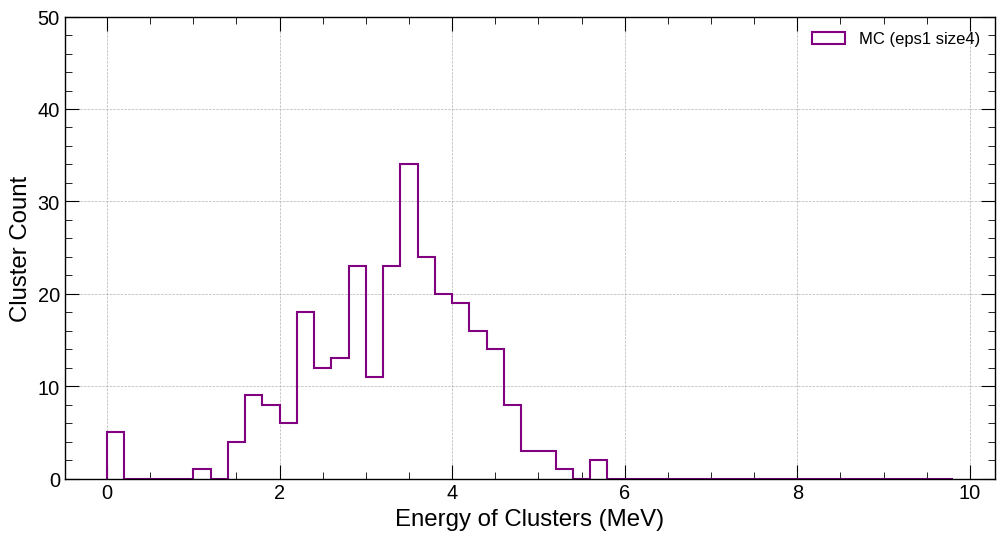

In [41]:
# Visualize the overlayed results

# Cluster energy

plt.figure(figsize=(12, 6))
#plt.figure(figsize=(6, 4))

#plt.hist(source_eps1size4_clusterE, linestyle=':', color='black', histtype='step', bins=np.arange(0,10,0.2), label='Source Data (eps1 size4)')
#plt.hist(nosource_eps1size4_clusterE, linestyle=':', color='red', histtype='step', bins=np.arange(0,10,0.2), label='No Source Data (eps1 size4)')
#plt.hist(nosource_MC_overlay_clustE, color='peru', histtype='step', bins=np.arange(0,10,0.2), label='MC + No Source Overlay (eps1 size4)')
plt.hist(MC_clustE, color='purple', histtype='step', bins=np.arange(0,10,0.2), label='MC (eps1 size4)')

#plt.text(7.0, 175.0, 'Overlay SNR=0.1')

plt.xlabel('Energy of Clusters (MeV)')
plt.ylabel('Cluster Count')
plt.grid(True)
#plt.yscale('log')
plt.ylim((0,50))
plt.legend()
plt.show()

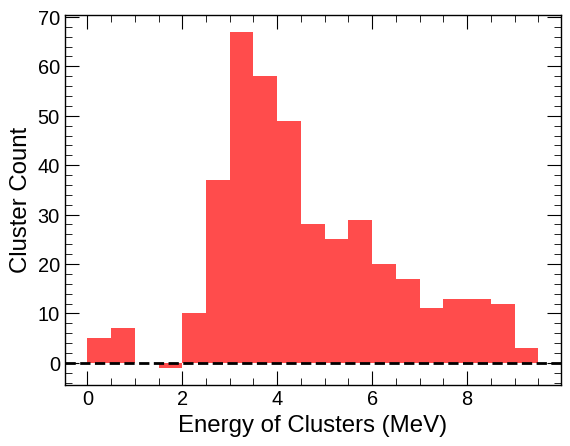

In [42]:
# Plot the difference
bins_range = np.arange(0,10,0.5)
source_data_counts, _ = np.histogram(source_eps1size4_clusterE, bins=bins_range)
nosource_data_counts, _ = np.histogram(nosource_eps1size4_clusterE, bins=bins_range)

# Calculate the difference
source_nosource_diff = source_data_counts - nosource_data_counts

# Plot the difference
plt.bar(bins_range[:-1], source_nosource_diff, width=np.diff(bins_range), align='edge', color='red', alpha=0.7)
plt.xlabel('Energy of Clusters (MeV)')
plt.ylabel('Cluster Count')
plt.axhline(0, color='black', linestyle='--') # Add baseline
plt.show()

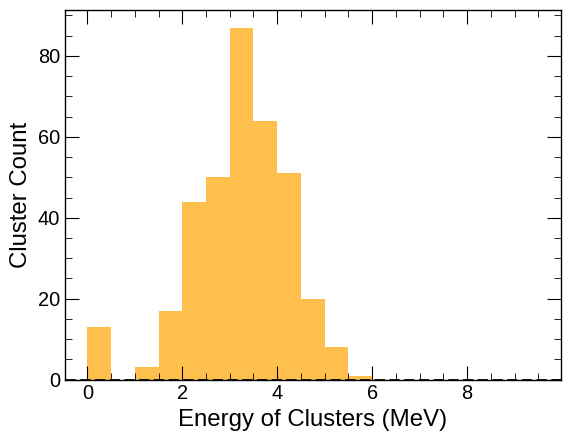

In [43]:
# Also plot the difference between background and overlay
# Plot the difference
bins_range = np.arange(0,10,0.5)
overlay_counts, _ = np.histogram(nosource_MC_overlay_clustE, bins=bins_range)
nosource_data_counts, _ = np.histogram(nosource_eps1size4_clusterE, bins=bins_range)

# Calculate the difference
overlay_nosource_diff = overlay_counts - nosource_data_counts

# Plot the difference
plt.bar(bins_range[:-1], overlay_nosource_diff, width=np.diff(bins_range), align='edge', color='orange', alpha=0.7)
plt.xlabel('Energy of Clusters (MeV)')
plt.ylabel('Cluster Count')
plt.axhline(0, color='black', linestyle='--') # Add baseline
plt.show()

In [44]:
print(len(source_eps1size4_clusterE[(8>=source_eps1size4_clusterE) & (source_eps1size4_clusterE>=2)]))
print(len(nosource_eps1size4_clusterE[(8>=nosource_eps1size4_clusterE) & (nosource_eps1size4_clusterE>=2)]))
print(sum([i*0.5 for i in source_nosource_diff]))

994
630
201.5


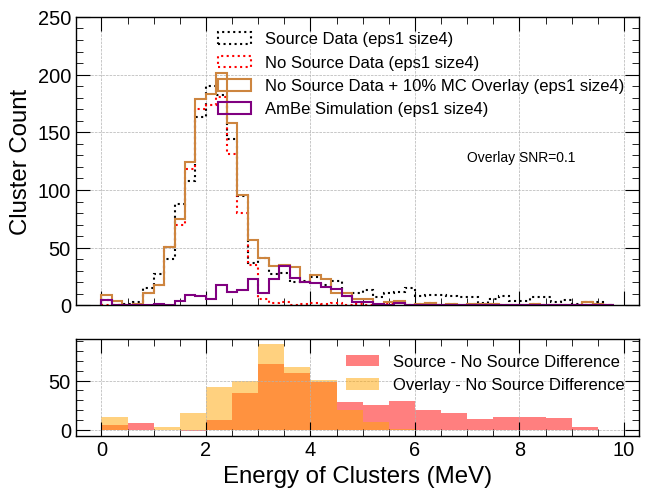

In [45]:
# Visualize the overlayed results along with the source-no source difference

# Cluster energy

f, (a0, a1) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

f.tight_layout()

a0.hist(source_eps1size4_clusterE, linestyle=':', color='black', histtype='step', bins=np.arange(0,10,0.2), label='Source Data (eps1 size4)')
a0.hist(nosource_eps1size4_clusterE, linestyle=':', color='red', histtype='step', bins=np.arange(0,10,0.2), label='No Source Data (eps1 size4)')
a0.hist(nosource_MC_overlay_clustE, color='peru', histtype='step', bins=np.arange(0,10,0.2), label='No Source Data + 10% MC Overlay (eps1 size4)')
a0.hist(MC_clustE, color='purple', histtype='step', bins=np.arange(0,10,0.2), label='AmBe Simulation (eps1 size4)')

# Also plot the source-no source difference
a1.bar(bins_range[:-1], source_nosource_diff, width=np.diff(bins_range), align='edge', facecolor='red', alpha=0.5, label='Source - No Source Difference')
a1.bar(bins_range[:-1], overlay_nosource_diff, width=np.diff(bins_range), align='edge', facecolor='orange', alpha=0.5, label='Overlay - No Source Difference')

a1.set_xlabel('Energy of Clusters (MeV)')
a0.set_ylabel('Cluster Count')
a0.text(7.0, 125.0, 'Overlay SNR=0.1')
a0.grid(True)
a1.grid(True)
#plt.yscale('log')
a0.set_ylim((0,250))
a0.legend()
a1.legend()
plt.show()

#TODO: In difference plot add: Overlay-no source difference
# Leave out MC template
# Include scaled MC template in the bottom plot instead

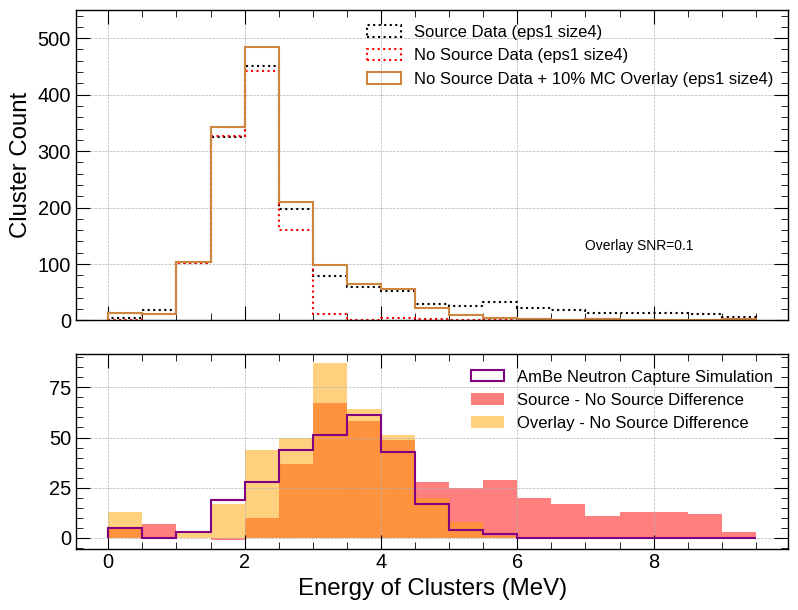

In [46]:
# Try changing the normalization by changing the estimated exposure, also change the MC to 10% of the original amount to mimick the SNR

# Visualize the overlayed results along with the source-no source difference

# Cluster energy

f, (a0, a1) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [8, 5]}, sharex=True, figsize=(8, 6))

f.tight_layout()

a0.hist(source_eps1size4_clusterE, linestyle=':', color='black', histtype='step', bins=np.arange(0,10,0.5), label='Source Data (eps1 size4)')
a0.hist(nosource_eps1size4_clusterE, linestyle=':', color='red', histtype='step', bins=np.arange(0,10,0.5), label='No Source Data (eps1 size4)')
a0.hist(nosource_MC_overlay_clustE, color='peru', histtype='step', bins=np.arange(0,10,0.5), label='No Source Data + 10% MC Overlay (eps1 size4)')

# Bottom plot that shows differences between datasets and simulated neutron captures
a1.bar(bins_range[:-1], source_nosource_diff, width=np.diff(bins_range), align='edge', facecolor='red', alpha=0.5, label='Source - No Source Difference')
a1.bar(bins_range[:-1], overlay_nosource_diff, width=np.diff(bins_range), align='edge', facecolor='orange', alpha=0.5, label='Overlay - No Source Difference')
a1.hist(MC_clustE, color='purple', histtype='step', bins=np.arange(0,10,0.5), label='AmBe Neutron Capture Simulation')

a1.set_xlabel('Energy of Clusters (MeV)')
a0.set_ylabel('Cluster Count')
a0.text(7.0, 125.0, 'Overlay SNR=0.1')
a0.grid(True)
a1.grid(True)
#plt.yscale('log')
a0.set_ylim((0,550))
a0.legend()
a1.legend()
plt.show()

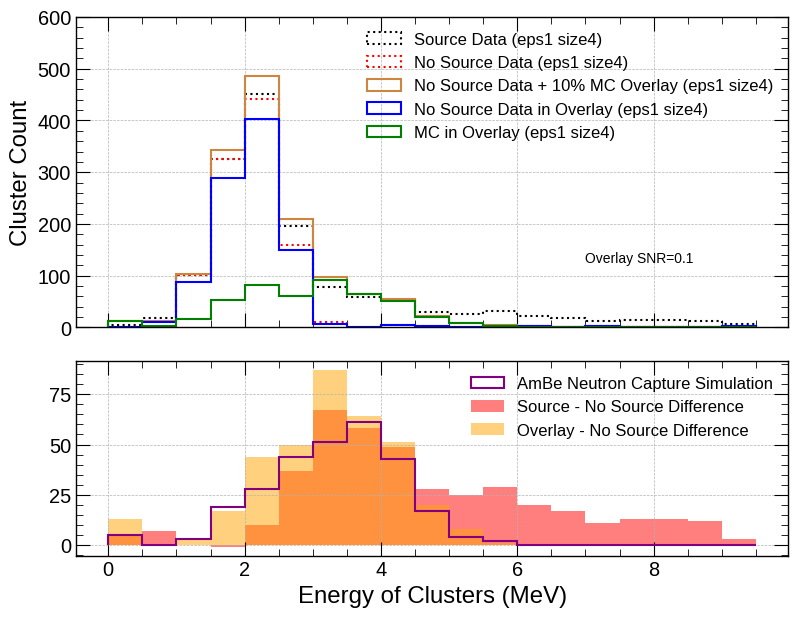

In [47]:
# Visualize the overlayed results along with the source-no source difference and the overlaid + bkg

# Cluster energy

f, (a0, a1) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [8, 5]}, sharex=True, figsize=(8, 6))

f.tight_layout()

a0.hist(source_eps1size4_clusterE, linestyle=':', color='black', histtype='step', bins=np.arange(0,10,0.5), label='Source Data (eps1 size4)')
a0.hist(nosource_eps1size4_clusterE, linestyle=':', color='red', histtype='step', bins=np.arange(0,10,0.5), label='No Source Data (eps1 size4)')
a0.hist(nosource_MC_overlay_clustE, color='peru', histtype='step', bins=np.arange(0,10,0.5), label='No Source Data + 10% MC Overlay (eps1 size4)')
a0.hist(nosource_MC_bkg_clustE, color='blue', histtype='step', bins=np.arange(0,10,0.5), label='No Source Data in Overlay (eps1 size4)')
a0.hist(nosource_MC_overlaid_clustE, color='green', histtype='step', bins=np.arange(0,10,0.5), label='MC in Overlay (eps1 size4)')

# Bottom plot that shows differences between datasets and simulated neutron captures
a1.bar(bins_range[:-1], source_nosource_diff, width=np.diff(bins_range), align='edge', facecolor='red', alpha=0.5, label='Source - No Source Difference')
a1.bar(bins_range[:-1], overlay_nosource_diff, width=np.diff(bins_range), align='edge', facecolor='orange', alpha=0.5, label='Overlay - No Source Difference')
a1.hist(MC_clustE, color='purple', histtype='step', bins=np.arange(0,10,0.5), label='AmBe Neutron Capture Simulation')

a1.set_xlabel('Energy of Clusters (MeV)')
a0.set_ylabel('Cluster Count')
a0.text(7.0, 125.0, 'Overlay SNR=0.1')
a0.grid(True)
a1.grid(True)
#plt.yscale('log')
a0.set_ylim((0,600))
a0.legend()
a1.legend()
plt.show()

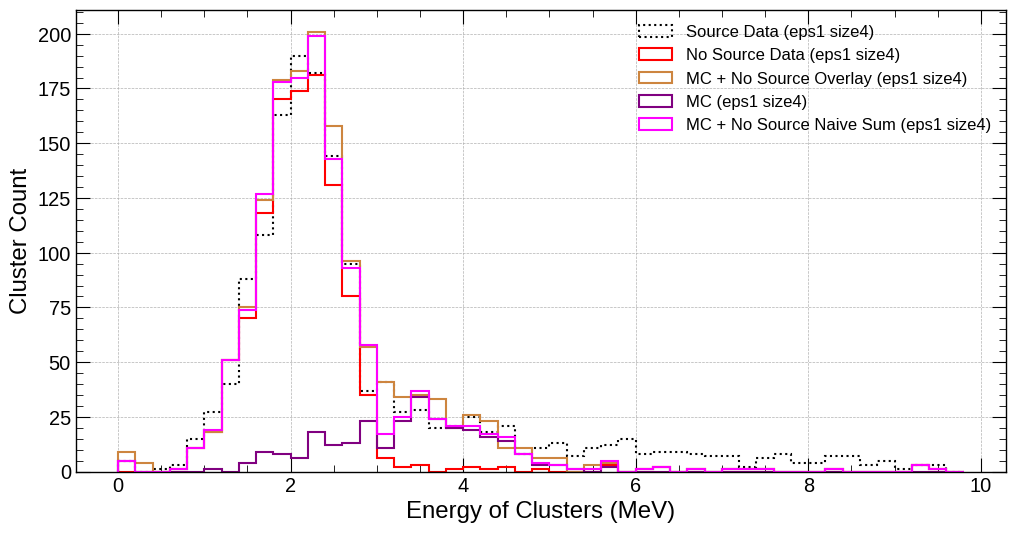

In [48]:
# Cluster energy

plt.figure(figsize=(12, 6))

plt.hist(source_eps1size4_clusterE, linestyle=':', color='black', histtype='step', bins=np.arange(0,10,0.2), label='Source Data (eps1 size4)')
plt.hist(nosource_eps1size4_clusterE, color='red', histtype='step', bins=np.arange(0,10,0.2), label='No Source Data (eps1 size4)')
plt.hist(nosource_MC_overlay_clustE, color='peru', histtype='step', bins=np.arange(0,10,0.2), label='MC + No Source Overlay (eps1 size4)')
plt.hist(MC_clustE, color='purple', histtype='step', bins=np.arange(0,10,0.2), label='MC (eps1 size4)')
plt.hist(naive_sum_clustE, color='magenta', histtype='step', bins=np.arange(0,10,0.2), label='MC + No Source Naive Sum (eps1 size4)')

plt.xlabel('Energy of Clusters (MeV)')
plt.ylabel('Cluster Count')
plt.grid(True)
#plt.yscale('log')
#plt.ylim((0,10))
plt.legend()
plt.show()

In [49]:
print(nosource_MC_overlay_clustE)

[0.19514672 2.85014799 1.3463461  ... 2.20438176 1.63144158 3.35041426]


In [50]:
# OVERLAY

# Event display of clusters at different energy range

#norm_df_nosource_MC_overlay[(norm_df_nosource_MC_overlay['file_id']==10.0) & (norm_df_nosource_MC_overlay['light_id']==1.0)]

# Select an event of interest
#df_nosource_MC_overlay_trig_id = [(i.split('::')[0], i.split('::')[1]) for i in norm_df_nosource_MC_overlay['id']]
plot_trig_id = (10.0,1.0)     # (file_id, light_id)
temp_df = norm_df_nosource_MC_overlay[(norm_df_nosource_MC_overlay['file_id'].astype(float)==plot_trig_id[0]) & (norm_df_nosource_MC_overlay['light_id'].astype(float)==plot_trig_id[1])]

for i in np.unique(temp_df['id']):
    print(f'Cluster Label: {i}; Cluster Energy: {sum(temp_df["E"][temp_df["id"]==i].astype(float))} MeV')

event_display(np.vstack([temp_df['x'].astype(float), temp_df['y'].astype(float), temp_df['z'].astype(float), temp_df['Q'].astype(float)]).T, 
              E=temp_df['E'].astype(float),
              cluster_label=temp_df['cluster_label'])

Cluster Label: 10.0::1.0::-1; Cluster Energy: 2.0792264069809243 MeV
Cluster Label: 10.0::1.0::0; Cluster Energy: 14.277087947644183 MeV
Cluster Label: 10.0::1.0::1; Cluster Energy: 9.394170612676568 MeV


In [51]:
# NO SOURCE DATA

# Event display of clusters at different energy range

# Select an event of interest
plot_trig_id = (10.0,1.0)     # (file_id, light_id)
temp_df = df_nosource_eps1size4[(df_nosource_eps1size4['file_id'].astype(float)==plot_trig_id[0]) & (df_nosource_eps1size4['light_id'].astype(float)==plot_trig_id[1])]

for i in np.unique(temp_df['id']):
    print(f'Cluster Label: {i}; Cluster Energy: {sum(temp_df["E"][temp_df["id"]==i].astype(float))} MeV')

event_display(np.vstack([temp_df['x'].astype(float), temp_df['y'].astype(float), temp_df['z'].astype(float), temp_df['Q'].astype(float)]).T, 
              E=temp_df['E'].astype(float),
              cluster_label=temp_df['cluster_label'])

Cluster Label: 10.0::1.0::-1.0; Cluster Energy: 0.362148149571127 MeV


In [ ]:
# SOURCE DATA

# Event display of clusters at different energy range

# Select an event of interest
#plot_trig_id = (0.0,1252.0)     # (file_id, light_id)
plot_trig_id = (23.0,2315.0)     # (file_id, light_id)
temp_df = df_eps1size4[(df_eps1size4['file_id'].astype(float)==plot_trig_id[0]) & (df_eps1size4['light_id'].astype(float)==plot_trig_id[1])]

for i in np.unique(temp_df['id']):
    print(f'Cluster Label: {i}; Cluster Energy: {sum(temp_df["E"][temp_df["id"]==i].astype(float))} MeV')

event_display(np.vstack([temp_df['x'].astype(float), temp_df['y'].astype(float), temp_df['z'].astype(float), temp_df['Q'].astype(float)]).T, 
              E=temp_df['E'].astype(float),
              cluster_label=temp_df['cluster_label'])

Cluster Label: 23.0::2315.0::-1.0; Cluster Energy: 23.004086146622114 MeV
Cluster Label: 23.0::2315.0::0.0; Cluster Energy: 66.73389759618058 MeV
Cluster Label: 23.0::2315.0::1.0; Cluster Energy: 1.7746997483693243 MeV
Cluster Label: 23.0::2315.0::2.0; Cluster Energy: 362.9836575853936 MeV
Cluster Label: 23.0::2315.0::3.0; Cluster Energy: 9.309261988502897 MeV
Cluster Label: 23.0::2315.0::4.0; Cluster Energy: 20.47139023392828 MeV
Cluster Label: 23.0::2315.0::5.0; Cluster Energy: 3.72172342323248 MeV
Cluster Label: 23.0::2315.0::6.0; Cluster Energy: 8.366038408107242 MeV
Cluster Label: 23.0::2315.0::7.0; Cluster Energy: 47.25027481214342 MeV


### Sideband fit to detemine the SNR of the Overlay

In [53]:
from scipy.optimize import curve_fit

In [54]:
# Define histograms

h_bins = np.arange(0,10,0.5)
h_bin_centers = 0.5 * (h_bins[:-1] + h_bins[1:])

h_overlay, _ = np.histogram(nosource_MC_overlaid_clustE, bins=h_bins)
h_bkg, _ = np.histogram(nosource_MC_bkg_clustE, bins=h_bins)
h_data, _ = np.histogram(source_eps1size4_clusterE, bins=h_bins)

In [55]:
# define the fit function
# Only fit to the bins in the 0-5MeV range

def overlay_by_snr(x, a, b):
    return a*h_bkg[:9]+b*h_overlay[:9]

In [56]:
# Only fit to the bins in the 0-5MeV range

pars,cov = curve_fit(overlay_by_snr, h_bin_centers[:9], h_data[:9], p0=[1, 1])

In [57]:
new_snr = 0.1*(pars[1]/pars[0])
print(pars)
print(f"SNR after performing the fit {new_snr}")

[0.95634633 0.8477577 ]
SNR after performing the fit 0.08864546985025532


In [58]:
h_fit = pars[0]*h_bkg+pars[1]*h_overlay

In [59]:
print(h_fit)

[ 11.02085012  11.25897875  97.72260069 322.16300666 454.92370448
 194.31741233  83.73178658  55.21283926  47.06102814  18.86784671
   7.73840795   3.60820807   2.869039     0.95634633   1.91269267
   0.95634633   0.95634633   0.           2.869039  ]


In [60]:
# Convert the list of bin centers into a histogram

print(nosource_data_counts)
print(_)

[  0  12 101 326 441 160  11   1   4   2   1   3   3   1   2   1   1   0
   3]
[0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5 6.  6.5 7.  7.5 8.  8.5
 9.  9.5]


In [61]:
# Calculate the difference between background and overlay
# Plot the difference
fitted_overlay_nosource_diff = h_fit - nosource_data_counts

In [62]:
# Reformat the source and no source histograms and calculate the uncertainty of each bin

source_clustE_hist, _ = np.histogram(source_eps1size4_clusterE, bins=bins_range)
nosource_clustE_hist, _ = np.histogram(nosource_eps1size4_clusterE, bins=bins_range)

source_clustE_hist_err = np.sqrt(source_clustE_hist)
nosource_clustE_hist_err = np.sqrt(nosource_clustE_hist)

In [63]:
MC_clust_E_hist, _ = np.histogram(MC_clustE, bins=bins_range)
#MC_clust_E_hist = MC_clust_E_hist/sum(source_nosource_diff)
MC_clust_E_hist_err = np.sqrt(MC_clust_E_hist)

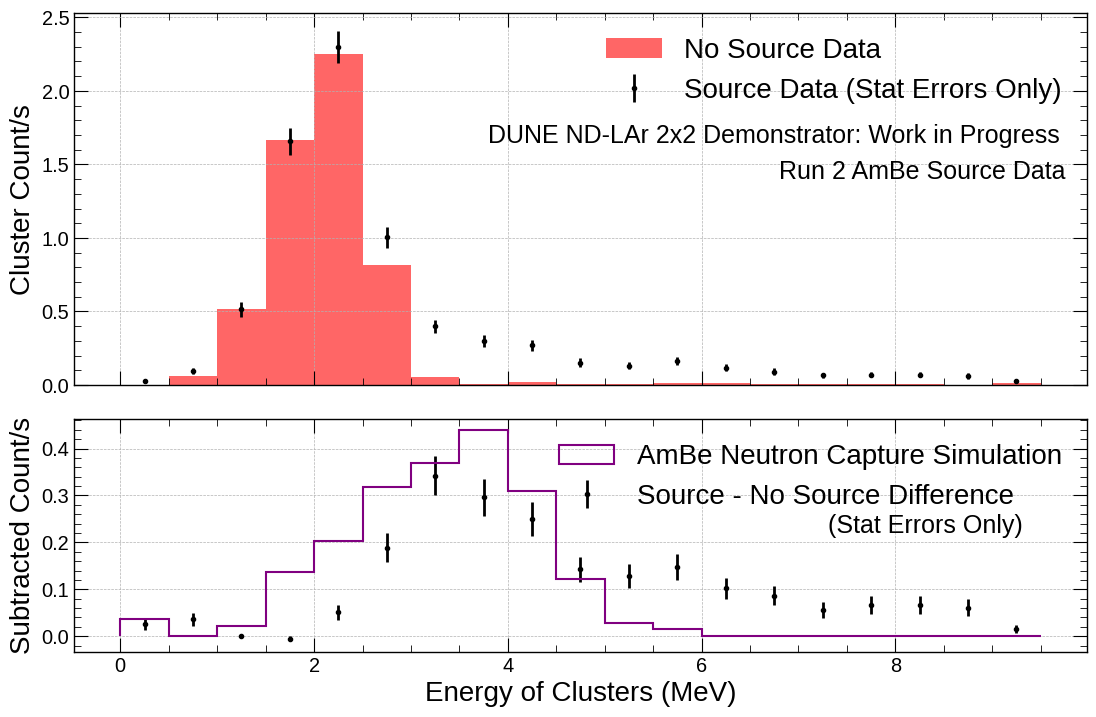

In [78]:
# Plot the fitted histogram

# NOTE: Normalized by runtime
runtime = no_source_runtime

f, (a0, a1) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [8, 5]}, sharex=True, figsize=(11, 7))

f.tight_layout()

a0.errorbar((bins_range+0.5*np.diff(bins_range)[0])[:-1], source_clustE_hist/runtime, yerr=source_clustE_hist_err/runtime, linestyle='none', color='black',  marker='.', label='Source Data (Stat Errors Only)')

#a0.hist(source_eps1size4_clusterE, linestyle=':', color='black', histtype='step', bins=np.arange(0,10,0.5), label='Source Data')
a0.hist(nosource_eps1size4_clusterE, weights=np.ones_like(nosource_eps1size4_clusterE)/runtime, linestyle='none', color='red', histtype='bar', bins=np.arange(0,10,0.5), label='No Source Data', alpha=0.6)
#a0.hist(nosource_MC_overlay_clustE, color='peru', histtype='step', bins=np.arange(0,10,0.5), label='No Source Data + 10% MC Overlay')
#a0.step(h_bin_centers, h_fit, where='mid', label='No Source Data + MC Overlay', color='peru', linewidth=1.5) #This is the fit result
#a0.bar(bins_range[:-1], h_fit, width=np.diff(bins_range), align='edge', label='No Source Data + MC Overlay', color='none', edgecolor='peru') #This is the fit result

# Bottom plot that shows differences between datasets and simulated neutron captures
a1.errorbar((bins_range+0.5*np.diff(bins_range)[0])[:-1], source_nosource_diff/runtime, yerr=np.sqrt(np.abs(source_nosource_diff))/runtime, linestyle='none', color='black', marker='.', label='Source - No Source Difference')
#a1.bar(bins_range[:-1], source_nosource_diff, width=np.diff(bins_range), align='edge', facecolor='red', alpha=0.5, label='Source - No Source Difference')
#a1.bar(bins_range[:-1], fitted_overlay_nosource_diff, width=np.diff(bins_range), align='edge', facecolor='orange', alpha=0.5, label='Overlay - No Source Difference')
a1.hist(MC_clustE, weights=np.ones(len(MC_clustE))*sum(abs(source_nosource_diff))/runtime, color='purple', histtype='step', bins=np.arange(0,10,0.5), label='AmBe Neutron Capture Simulation', density=True)
#a1.bar(bins_range[:-1], MC_clust_E_hist*(sum(abs(source_nosource_diff))/runtime), width=np.diff(bins_range), align='edge', color='purple', label='AmBe Neutron Capture Simulation')
#a1.bar(bins_range[:-1], MC_clust_E_hist, width=np.diff(bins_range), align='edge', color='purple', label='AmBe Neutron Capture Simulation')

a1.set_xlabel('Energy of Clusters (MeV)', fontsize=20)
a1.set_ylabel('Subtracted Count/s', fontsize=20)
a0.set_ylabel('Cluster Count/s', fontsize=20)
#a0.text(7.0, 125.0, f'Overlay SNR={new_snr:.3f}')
a0.text(3.8, 1.65, 'DUNE ND-LAr 2x2 Demonstrator: Work in Progress', fontsize=18)
a0.text(6.8, 1.4, 'Run 2 AmBe Source Data', fontsize=18)
a1.text(7.3, 0.22, '(Stat Errors Only)', fontsize=18)
a0.grid(True)
a1.grid(True)
#plt.yscale('log')
#a0.set_ylim((0,550))
a0.legend(fontsize=20)
a1.legend(fontsize=20)
plt.show()

In [65]:
MC_clust_E_hist*(sum(abs(source_nosource_diff))/runtime)

array([ 10.33163265,   0.        ,   6.19897959,  39.26020408,
        57.85714286,  90.91836735, 105.38265306, 126.04591837,
        88.85204082,  35.12755102,   8.26530612,   4.13265306,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ])

In [66]:
# export source-no_source difference

np.savetxt('../output/cluster_energy/source_nosource_diff.csv', source_nosource_diff, delimiter=',')

In [67]:
print(sum(abs(source_nosource_diff)))
print(sum(MC_clustE))
print(np.histogram(MC_clustE))

405
913.9986694875422
(array([ 5,  1, 11, 27, 46, 54, 69, 46, 14,  4]), array([0.06680549, 0.6315103 , 1.19621512, 1.76091993, 2.32562474,
       2.89032955, 3.45503436, 4.01973917, 4.58444398, 5.14914879,
       5.7138536 ]))


### Additional Cluster Size Cut

In [68]:
# The cut
min_clust_size = 6

In [69]:
source_clustE_selected = source_eps1size4_clusterE[source_eps1size4_clusterhitcount>=min_clust_size]
nosource_clustE_selected = nosource_eps1size4_clusterE[nosource_eps1size4_clusterhitcount>=min_clust_size]

In [70]:
# Reformat the source and no source histograms and calculate the uncertainty of each bin

source_clustE_selected_hist, _ = np.histogram(source_clustE_selected, bins=bins_range)
nosource_clustE_selected_hist, _ = np.histogram(nosource_clustE_selected, bins=bins_range)

source_clustE_selected_hist_err = np.sqrt(source_clustE_selected_hist)
nosource_clustE_selected_hist_err = np.sqrt(nosource_clustE_selected_hist)

In [71]:
source_nosource_diff_selected = source_clustE_selected_hist - nosource_clustE_selected_hist

In [72]:
MC_clust_E_hist

array([ 5,  0,  3, 19, 28, 44, 51, 61, 43, 17,  4,  2,  0,  0,  0,  0,  0,
        0,  0])

In [73]:
# Export the histograms after selection cuts
np.savetxt('../output/cluster_energy/source_nosource_diff_selected.csv', source_nosource_diff_selected, delimiter=',')
np.savetxt('../output/cluster_energy/MC_clustE.csv', MC_clustE, delimiter=',')

In [74]:
print(sum(abs(source_nosource_diff_selected))/runtime)
print(sum(abs(source_nosource_diff))/runtime)

1.4795918367346939
2.066326530612245


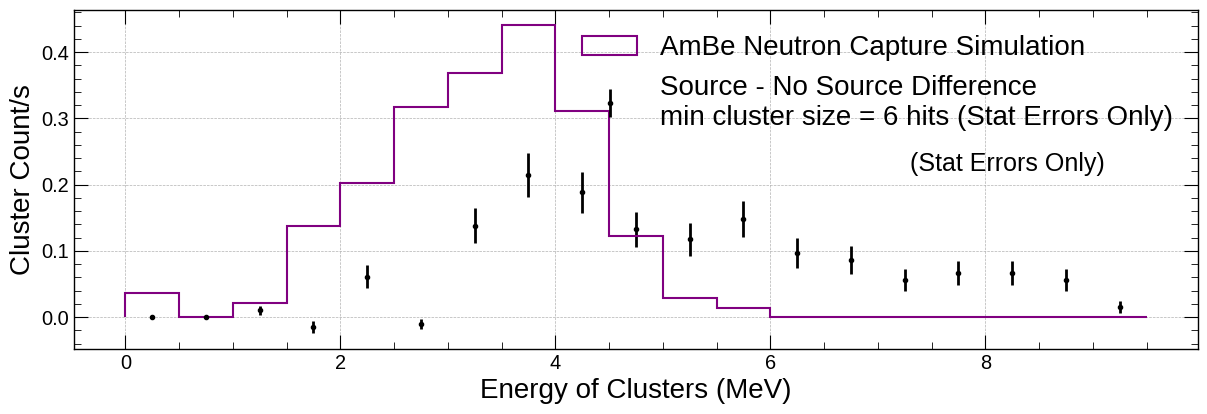

In [75]:
runtime = no_source_runtime

f, a1 = plt.subplots(figsize=(12, 4))

f.tight_layout()

# Bottom plot that shows differences between datasets and simulated neutron captures
a1.errorbar((bins_range+0.5*np.diff(bins_range)[0])[:-1], source_nosource_diff_selected/runtime, yerr=np.sqrt(np.abs(source_nosource_diff_selected))/runtime, linestyle='none', color='black', marker='.', label='Source - No Source Difference\nmin cluster size = 6 hits (Stat Errors Only)')
a1.hist(MC_clustE, weights=np.ones(len(MC_clustE))*sum(abs(source_nosource_diff_selected))/runtime, color='purple', histtype='step', bins=np.arange(0,10,0.5), label='AmBe Neutron Capture Simulation', density=True)

a1.set_xlabel('Energy of Clusters (MeV)', fontsize=20)
a1.set_ylabel('Cluster Count/s', fontsize=20)
#a0.text(3.8, 1.65, 'DUNE ND-LAr 2x2 Demonstrator: Work in Progress', fontsize=18)
#a0.text(6.8, 1.4, 'Run 2 AmBe Source Data', fontsize=18)
a1.text(7.3, 0.22, '(Stat Errors Only)', fontsize=18)

a1.grid(True)
#plt.yscale('log')
#a0.set_ylim((0,550))
a1.legend(fontsize=20)
plt.show()

In [76]:
print(no_source_runtime)

196


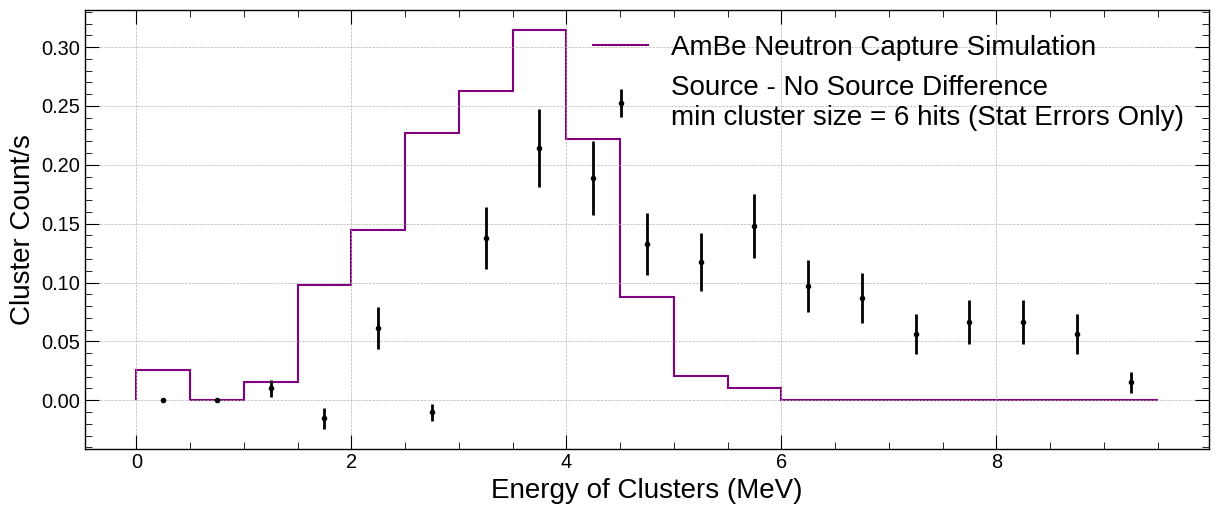

In [77]:
runtime = no_source_runtime

f, a1 = plt.subplots(figsize=(12, 5))
f.tight_layout()

# Data histogram represented by error bars
bin_centers = (bins_range + 0.5*np.diff(bins_range)[0])[:-1]
bin_widths = np.diff(bins_range)

data_counts = source_nosource_diff_selected / runtime
data_errors = np.sqrt(np.abs(source_nosource_diff_selected)) / runtime

a1.errorbar(
    bin_centers,
    data_counts,
    yerr=data_errors,
    linestyle='none',
    color='black',
    marker='.',
    label='Source - No Source Difference\nmin cluster size = 6 hits (Stat Errors Only)'
)

# MC histogram
mc_bins = np.arange(0, 10, 0.5)
mc_counts, mc_edges = np.histogram(MC_clustE, bins=mc_bins)

# Area under the data histogram
data_area = np.sum(data_counts * bin_widths)

# Area under the raw MC histogram
mc_bin_widths = np.diff(mc_edges)
mc_area = np.sum(mc_counts * mc_bin_widths)

# Scale MC to match the data histogram area
scale_factor = data_area / mc_area

a1.stairs(
    mc_counts * scale_factor,
    mc_edges,
    color='purple',
    label='AmBe Neutron Capture Simulation'
)

a1.set_xlabel('Energy of Clusters (MeV)', fontsize=20)
a1.set_ylabel('Cluster Count/s', fontsize=20)

a1.grid(True)
a1.legend(fontsize=20)

plt.show()

### Fiducial Volume Cut

In [ ]:
# Rough FV cut, not cutting entire clusters yet

def FV_Cut(df_in):

    # Conduct a fiducial volume cut for source present data that divides the TPC into top and bottom half

    df_top = df_in[df_in['y']>0]
    E_clust_top = []

    for i in np.unique(df_top['id'])[:n_source]:
        tempsum = sum(df_top['E'][(df_top['id']==i) & (df_top['cluster_label']!=-1)].astype(float))
        if tempsum==0:
            pass
        else:
            E_clust_top.append(tempsum)

    E_clust_top = np.array(E_clust_top)

    df_bottom = df_in[df_in['y']<=0]
    E_clust_bottom = []

    for i in np.unique(df_bottom['id'])[:n_source]:
        tempsum = sum(df_bottom['E'][(df_bottom['id']==i) & (df_bottom['cluster_label']!=-1)].astype(float))
        if tempsum==0:
            pass
        else:
            E_clust_bottom.append(tempsum)

    E_clust_bottom = np.array(E_clust_bottom)

    return df_top, E_clust_top, df_bottom, E_clust_bottom

In [ ]:
# Make the same comparisons as above but look at the top and bottom halves of the TPCs separately

df_data_top, E_data_clust_top, df_data_bottom, E_data_clust_bottom = FV_Cut(df_eps1size4)

In [ ]:
df_nosource_top, E_nosource_clust_top, df_nosource_bottom, E_nosource_clust_bottom = FV_Cut(df_nosource_eps1size4)

In [ ]:
# Top half if all TPCs

f, (a0, a1) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [8, 5]}, sharex=True, figsize=(8, 6))

f.tight_layout()

a0.hist(E_data_clust_top, linestyle=':', color='black', histtype='step', bins=np.arange(0,10,0.5), label='Source Data')
a0.hist(E_nosource_clust_top, linestyle=':', color='red', histtype='step', bins=np.arange(0,10,0.5), label='No Source Data')
#a0.hist(nosource_MC_overlay_clustE, color='peru', histtype='step', bins=np.arange(0,10,0.5), label='No Source Data + 10% MC Overlay')
#a0.step(h_bin_centers, h_fit, where='mid', label='Fit Result', color='blue', linewidth=1.5)

# Bottom plot that shows differences between datasets and simulated neutron captures
a1.bar(bins_range[:-1], source_nosource_diff, width=np.diff(bins_range), align='edge', facecolor='red', alpha=0.5, label='Source - No Source Difference')
#a1.bar(bins_range[:-1], overlay_nosource_diff, width=np.diff(bins_range), align='edge', facecolor='orange', alpha=0.5, label='Overlay - No Source Difference')
a1.hist(MC_clustE, color='purple', histtype='step', bins=np.arange(0,10,0.5), label='AmBe Neutron Capture Simulation')

a1.set_xlabel('Energy of Clusters (MeV)')
a0.set_ylabel('Cluster Count')
a0.text(7.0, 125.0, 'Overlay SNR=0.1')
a0.grid(True)
a1.grid(True)
#plt.yscale('log')
a0.set_ylim((0,300))
a0.legend()
a1.legend()
plt.show()

In [ ]:
# Bottom half of all TPCs

f, (a0, a1) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [8, 5]}, sharex=True, figsize=(8, 6))

f.tight_layout()

a0.hist(E_data_clust_bottom, linestyle=':', color='black', histtype='step', bins=np.arange(0,10,0.5), label='Source Data')
a0.hist(E_nosource_clust_bottom, linestyle=':', color='red', histtype='step', bins=np.arange(0,10,0.5), label='No Source Data')
#a0.hist(nosource_MC_overlay_clustE, color='peru', histtype='step', bins=np.arange(0,10,0.5), label='No Source Data + 10% MC Overlay')
#a0.step(h_bin_centers, h_fit, where='mid', label='Fit Result', color='blue', linewidth=1.5)

# Bottom plot that shows differences between datasets and simulated neutron captures
a1.bar(bins_range[:-1], source_nosource_diff, width=np.diff(bins_range), align='edge', facecolor='red', alpha=0.5, label='Source - No Source Difference')
#a1.bar(bins_range[:-1], overlay_nosource_diff, width=np.diff(bins_range), align='edge', facecolor='orange', alpha=0.5, label='Overlay - No Source Difference')
a1.hist(MC_clustE, color='purple', histtype='step', bins=np.arange(0,10,0.5), label='AmBe Neutron Capture Simulation')

a1.set_xlabel('Energy of Clusters (MeV)')
a0.set_ylabel('Cluster Count')
a0.text(7.0, 125.0, 'Overlay SNR=0.1')
a0.grid(True)
a1.grid(True)
#plt.yscale('log')
a0.set_ylim((0,300))
a0.legend()
a1.legend()
plt.show()

### Mass Produce event displays of all clusters

In [ ]:
def get_quickimg(df_in):
    # Function for generating event display images

    evt_ids = df_in['file_id'].astype(str)+ '::' + df_in['light_id'].astype(str)
    for i in np.unique(evt_ids):
        evt_to_plot = df_in[evt_ids==i]

        # Create scatter plot
        plt.figure(figsize=(8, 6))

        scatter = plt.scatter(
            evt_to_plot['x'],
            evt_to_plot['y'],
            c=evt_to_plot['E'],          # Color mapped to energy
            cmap='Blues',       # Greyscale colormap
            s=60,              # Marker size
        )

        # Add colorbar to show energy scale
        cbar = plt.colorbar(scatter)
        cbar.set_label('Energy (MeV)')

        # Labels and title
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title(f'file_id::light_id:{i}')

        plt.show()
        break

    return

In [ ]:
get_quickimg(df_eps1size4)

### Process and plot all available prompt trigger data

In [ ]:
# Load cluster results

#AmBe_mod2_pmt_trigger_100us_period_clusters_df = pd.read_csv('/global/cfs/cdirs/dune/users/lmlepin/cluster_outputs/AmBe_mod2_pmt_trigger_100us_period_20260409_1827')    # No data available for now

AmBe_mod2_pmt_trigger_109us_period_clusters_prompt_df = pd.read_csv('/global/cfs/cdirs/dune/users/lmlepin/cluster_outputs/AmBe_mod2_pmt_trigger_109us_period_20260409_1510/AmBe_mod2_pmt_trigger_109us_period_clusters_prompt.csv')
AmBe_mod2_pmt_trigger_109us_period_clusters_delayed_df = pd.read_csv('/global/cfs/cdirs/dune/users/lmlepin/cluster_outputs/AmBe_mod2_pmt_trigger_109us_period_20260409_1510/AmBe_mod2_pmt_trigger_109us_period_clusters_delayed.csv')

AmBe_mod2_pmt_trigger_128us_period_clusters_prompt_df = pd.read_csv('/global/cfs/cdirs/dune/users/lmlepin/cluster_outputs/AmBe_mod2_pmt_trigger_128us_period_20260409_1524/AmBe_mod2_pmt_trigger_128us_period_clusters_prompt.csv')
AmBe_mod2_pmt_trigger_128us_period_clusters_delayed_df = pd.read_csv('/global/cfs/cdirs/dune/users/lmlepin/cluster_outputs/AmBe_mod2_pmt_trigger_128us_period_20260409_1524/AmBe_mod2_pmt_trigger_128us_period_clusters_delayed.csv')

AmBe_mod2_pmt_trigger_147us_period_clusters_prompt_df = pd.read_csv('/global/cfs/cdirs/dune/users/lmlepin/cluster_outputs/AmBe_mod2_pmt_trigger_147us_period_20260409_1535/AmBe_mod2_pmt_trigger_147us_period_clusters_prompt.csv')
AmBe_mod2_pmt_trigger_147us_period_clusters_delayed_df = pd.read_csv('/global/cfs/cdirs/dune/users/lmlepin/cluster_outputs/AmBe_mod2_pmt_trigger_147us_period_20260409_1535/AmBe_mod2_pmt_trigger_147us_period_clusters_delayed.csv')

AmBe_mod2_pmt_trigger_176us_period_clusters_prompt_df = pd.read_csv('/global/cfs/cdirs/dune/users/lmlepin/cluster_outputs/AmBe_mod2_pmt_trigger_176us_period_20260409_1539/AmBe_mod2_pmt_trigger_176us_period_clusters_prompt.csv')
AmBe_mod2_pmt_trigger_176us_period_clusters_delayed_df = pd.read_csv('/global/cfs/cdirs/dune/users/lmlepin/cluster_outputs/AmBe_mod2_pmt_trigger_176us_period_20260409_1539/AmBe_mod2_pmt_trigger_176us_period_clusters_delayed.csv')

AmBe_mod2_pmt_trigger_195us_period_clusters_prompt_df = pd.read_csv('/global/cfs/cdirs/dune/users/lmlepin/cluster_outputs/AmBe_mod2_pmt_trigger_195us_period_20260409_1557/AmBe_mod2_pmt_trigger_195us_period_clusters_prompt.csv')
AmBe_mod2_pmt_trigger_195us_period_clusters_delayed_df = pd.read_csv('/global/cfs/cdirs/dune/users/lmlepin/cluster_outputs/AmBe_mod2_pmt_trigger_195us_period_20260409_1557/AmBe_mod2_pmt_trigger_195us_period_clusters_delayed.csv')

AmBe_mod2_pmt_trigger_224us_period_clusters_prompt_df = pd.read_csv('/global/cfs/cdirs/dune/users/lmlepin/cluster_outputs/AmBe_mod2_pmt_trigger_224us_period_20260409_1557/AmBe_mod2_pmt_trigger_224us_period_clusters_prompt.csv')
AmBe_mod2_pmt_trigger_224us_period_clusters_delayed_df = pd.read_csv('/global/cfs/cdirs/dune/users/lmlepin/cluster_outputs/AmBe_mod2_pmt_trigger_224us_period_20260409_1557/AmBe_mod2_pmt_trigger_224us_period_clusters_delayed.csv')